# Preparing for the Simulation


## Libraries


In [3]:
# ============================================================
# 1. Installation and environment setup
# ============================================================
!pip install -U tabpfn-client huggingface_hub catboost==1.2.10 xgboost==3.2.0 tabpfn==6.0.6

In [7]:
# --- Libraries ---
import os
from huggingface_hub import login
from importlib.metadata import version

#Importing TabPFN
# ============================================================================
# Choose TabPFN - exploratory -
# Always set USE_TABPFN_CLIENT = False for final results
#   Set USE_TABPFN_CLIENT = True  → use cloud API by https://ux.priorlabs.ai
#   Set USE_TABPFN_CLIENT = False → use local model - CPU
USE_TABPFN_CLIENT = False #<- change it based on above
# ============================================================================

# HuggingFace token
your_hf_token = "asd" # replace with your own token
# TabPFN token Client
your_tabpfn_TOKEN = "asd" # replace with your own token

if USE_TABPFN_CLIENT:
    import tabpfn_client
    from tabpfn_client import TabPFNClassifier, set_access_token
    # Authenticate with token
    set_access_token(your_tabpfn_TOKEN)
    print("Using TabPFN client (cloud inference)")
    print("TabPFN client version:", version("tabpfn-client"))
else:
    os.environ["TABPFN_TOKEN"] = your_tabpfn_TOKEN
    os.environ["TABPFN_NO_BROWSER"] = "1"
    login(token=your_hf_token)
    from tabpfn import TabPFNClassifier
    print("Using local TabPFN (model weights will be downloaded)")
    print("TabPFN package version:", version("tabpfn"))


# Mounting Google drive
from google.colab import drive

import logging  # logging events, errors, and debug info
import sys  # system-specific parameters (argv, path, exit)
import ast  # evaluation of Python literals
import re  # regular expressions for text
from contextlib import contextmanager
import warnings  # Suppress or handle warnings
import time  # Time  measurement
from tqdm import tqdm  # Progress bars for loops
import gc

import numpy as np
import pandas as pd
import torch  # deep learning framework

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid') # clean grid, no background shading
import plotly.graph_objects as go  # interactive visualizations
from plotly.subplots import make_subplots  # multi-plot interactive

from scipy.stats import multivariate_normal, multivariate_t
from scipy.linalg import block_diag  # Block diagonal matrix construction
from scipy.special import logit

from imblearn.over_sampling import SMOTE  # Synthetic oversampling for imbalanced classes
from imblearn.under_sampling import RandomUnderSampler  # Random undersampling for majority class

from sklearn.metrics import roc_curve, balanced_accuracy_score, roc_auc_score, mean_squared_error  # Evaluation metrics
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV  # Linear classification with cross-validation
from sklearn.ensemble import RandomForestClassifier  # Tree ensemble
from sklearn.model_selection import GridSearchCV, train_test_split  # Hyperparameter tuning and data splitting
from sklearn.exceptions import ConvergenceWarning  # Specific warning for iterative algorithms
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier, callback  # Extreme Gradient Boosting with training callbacks
from catboost import CatBoostClassifier, Pool  # Categorical boosting with optimized data structure

Using local TabPFN (model weights will be downloaded)
TabPFN package version: 6.0.6


## Google Drive and TabPFn access

In [11]:
# Mountiing Google Drive and
drive.mount('/content/drive')

Mounted at /content/drive


# Models & Simulation Function

1.   Modeling
2.   Whole simulation
3.   Saving results
4.   Suppressing excesive printing



## 1. Fitting a Model for each approach

**Methods Selected vs. Tunning Situation**

| Method | Tuning | Settings (On/Off) |
|--------|--------|-------------------|
| Linear Sparse LR | GridCV on C | Imbalance: Off; Device: CPU (n_jobs=1); Early Stop: NA ; Aug: Off |
| Augmented Sparse LR | GridCV on C post-aug | Imbalance: Off; Device: CPU (n_jobs=1); Early Stop: NA; Aug: On |
| Random Forest | GridCV on n_est/depth | Imbalance: Off; Device: CPU (n_jobs=1); Early Stop: NA; Aug: Off |
| XGBoost | GridCV on n_est/depth | Imbalance: Off; Device: CPU (hist, n_jobs=1); Early Stop: Off; Aug: Off |
| CatBoost | GridCV on iter/depth |  Imbalance: Off; Device: CPU (default); Early Stop: Off; Aug: Off |
| TabPFN (No Tune) | None |  Imbalance: Off; Device: CPU; Early Stop: Off; Aug: Off; Suppress Output: On |





In [ ]:
##########################################
### --- Augment Features Function  --- ###
##########################################

def augment_features(X):
    """Augment function: add pairwise feature interactions efficiently."""
    n, d = X.shape
    # all pairwise interactions using matrix operations
    idx = np.triu_indices(d, k=0)  # indices for upper triangle + diagonal
    xx = X[:, idx[0]] * X[:, idx[1]]  # element-wise multiplication for pairwise
    return np.hstack((X, xx))

In [ ]:
##########################################
### ---        Model Runners       --- ###
##########################################


# Models are defined to ensure neutral simulation comparison as possible based
#    on the following:

# 1. Hyperparameter Tuning: All models use GridSearchCV with a separate
#    validation set to tune key parameters (C for logistic regression,
#    n_estimators/max_depth for Random Forest/XGBoost/CatBoost, nothing for
#    TabPFN since it claims no tunning required)

# 2. Class Imbalance: No imbalance handling; models train on original
#    unbalanced data.

# 3. Model Complexity: Tree-based models use increased base complexity
#    (n_estimators=100, max_depth=5 or 6) as starting points for tuning to
#    align with typical defaults.

# 4. Computational Resources: TabPFN set to device='cpu' to standardize hardware
#    usage, ensuring runtime comparisons on the same compuatation power.

# 5. Metrics: Retained original metrics (ROC AUC, MSE, FPR, TPR)

##########################################
### Linear Sparse Logistic Regression  ###
##########################################

def run_linear_sparse_logistic_regression(X_train, X_test, y_train, y_test, X_train_sub, y_train_sub, X_val, y_val):
    # model and tuning grid
    lr = LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=2000,
        n_jobs=1,
    )
    param_grid = {'C': np.logspace(-4, 4, 10)}
    grid_search = GridSearchCV(
        lr,
        param_grid,
        cv=[(np.arange(len(X_train_sub)), np.arange(len(X_train_sub), len(X_train_sub) + len(X_val)))],  # train/val split
        scoring='roc_auc',
        n_jobs=1
    )
    grid_search.fit(np.vstack((X_train_sub, X_val)), np.hstack((y_train_sub, y_val)))
    best_model = grid_search.best_estimator_

    # best model on full training data
    best_model.fit(X_train, y_train)

    # predict + compute metrics
    pred = best_model.predict(X_test)
    proba = best_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    return (
        balanced_accuracy_score(y_test, pred),
        roc_auc_score(y_test, proba),
        mean_squared_error(y_test, pred),
        fpr,
        tpr,
        proba
    )

##############################################################
### Sparse Logistic Regression on Augmented Feature Space  ###
##############################################################

def run_sparse_logistic_regression(X_train, X_test, y_train, y_test, X_train_sub, y_train_sub, X_val, y_val):
    # augmentation first
    Aug_X_train = augment_features(X_train)
    Aug_X_test = augment_features(X_test)
    Aug_X_train_sub = augment_features(X_train_sub)
    Aug_X_val = augment_features(X_val)

    # model and tuning grid
    lr = LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=2000,
        n_jobs=1,
        #class_weight='balanced'  # Handle class imbalance
    )
    param_grid = {'C': np.logspace(-4, 4, 10)}
    grid_search = GridSearchCV(
        lr,
        param_grid,
        cv=[(np.arange(len(Aug_X_train_sub)), np.arange(len(Aug_X_train_sub), len(Aug_X_train_sub) + len(Aug_X_val)))],
        scoring='roc_auc',
        n_jobs=1
    )
    grid_search.fit(np.vstack((Aug_X_train_sub, Aug_X_val)), np.hstack((y_train_sub, y_val)))
    best_model = grid_search.best_estimator_

    # best model on full augmented training data
    best_model.fit(Aug_X_train, y_train)

    # predict and compute metrics
    pred = best_model.predict(Aug_X_test)
    proba = best_model.predict_proba(Aug_X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    return (
        balanced_accuracy_score(y_test, pred),
        roc_auc_score(y_test, proba),
        mean_squared_error(y_test, pred),
        fpr,
        tpr,
        proba
    )

##########################################
###        --- Random Forest ---       ###
##########################################

def run_random_forest(X_train, X_test, y_train, y_test, X_train_sub, y_train_sub, X_val, y_val):
    # model and tuning grid
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        n_jobs=1,
        #class_weight='balanced'  # Handle class imbalance
    )
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, None]
    }  # number of trees and depth
    grid_search = GridSearchCV(
        rf,
        param_grid,
        cv=[(np.arange(len(X_train_sub)), np.arange(len(X_train_sub), len(X_train_sub) + len(X_val)))],  # Train/val split
        scoring='roc_auc',
        n_jobs=1
    )
    grid_search.fit(np.vstack((X_train_sub, X_val)), np.hstack((y_train_sub, y_val)))
    best_model = grid_search.best_estimator_

    # train best model on full train
    best_model.fit(X_train, y_train)

    # predict and compute metrics
    pred = best_model.predict(X_test)
    proba = best_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    return (
        balanced_accuracy_score(y_test, pred),
        roc_auc_score(y_test, proba),
        mean_squared_error(y_test, pred),
        fpr,
        tpr,
        proba
    )

##########################################
###           --- XGBoost ---          ###
##########################################

def run_xgboost(X_train, X_test, y_train, y_test, X_train_sub, y_train_sub, X_val, y_val):

    # Define model and tuning grid
    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=6,       # default-like depth
        learning_rate=0.1,
        eval_metric='logloss',
        tree_method='hist',
        n_jobs=1
    )
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 6]
    }  # number of trees and depth
    grid_search = GridSearchCV(
        xgb,
        param_grid,
        cv=[(np.arange(len(X_train_sub)), np.arange(len(X_train_sub), len(X_train_sub) + len(X_val)))],  # Train/val split
        scoring='roc_auc',
        n_jobs=1
    )
    grid_search.fit(np.vstack((X_train_sub, X_val)), np.hstack((y_train_sub, y_val)))
    best_model = grid_search.best_estimator_

    # best model on full train data
    best_model.fit(X_train, y_train)

    # predict and compute metrics
    pred = best_model.predict(X_test)
    proba = best_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    return (
        balanced_accuracy_score(y_test, pred),
        roc_auc_score(y_test, proba),
        mean_squared_error(y_test, pred),
        fpr,
        tpr,
        proba
    )

##########################################
###          --- CatBoost ---          ###
##########################################

def run_catboost(X_train, X_test, y_train, y_test, X_train_sub, y_train_sub, X_val, y_val):
    #  model and tuning grid
    cb = CatBoostClassifier(
        iterations=100,
        depth=6,         # default-like depth
        learning_rate=0.1,
        verbose=0
    )
    param_grid = {
        'iterations': [50, 100, 200],
        'depth': [3, 5, 6]
    }  # tune number of iterations and depth
    grid_search = GridSearchCV(
        cb,
        param_grid,
        cv=[(np.arange(len(X_train_sub)), np.arange(len(X_train_sub), len(X_train_sub) + len(X_val)))],  # Train/val split
        scoring='roc_auc',
        n_jobs=1
    )
    grid_search.fit(np.vstack((X_train_sub, X_val)), np.hstack((y_train_sub, y_val)))
    best_model = grid_search.best_estimator_

    # train best model
    best_model.fit(X_train, y_train)

    # predict/ compute metrics
    pred = best_model.predict(X_test)
    proba = best_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    return (
        balanced_accuracy_score(y_test, pred),
        roc_auc_score(y_test, proba),
        mean_squared_error(y_test, pred),
        fpr,
        tpr,
        proba
    )

##########################################
###           --- TabPFN ---           ###
##########################################
def run_tabpfn(X_train, X_test, y_train, y_test, rs):
    """
    Run TabPFN – returns (bal_acc, AUC, MSE, fpr, tpr, proba)
    Works with both local (tabpfn) and client (tabpfn_client) backends.

    Modified: Added StandardScaler to match TabPFN's expectation of
    standardized features (zero mean, unit variance).
    """
    # --- Scale features (critical for TabPFN) ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    if USE_TABPFN_CLIENT:
        # Client version: uses GPU - be carefull - runtime faster
        with suppress_output():
            tabpfn = TabPFNClassifier()
    else:
        # Local version: no tuning and cpu
        with suppress_output():
            tabpfn = TabPFNClassifier(
                n_estimators=1,          # Single model for instant inference
                device='cpu',            # Match other models
                inference_precision='auto',
                n_jobs=1,
                ignore_pretraining_limits=True
            )

    with suppress_output():
        tabpfn.fit(X_train_scaled, y_train)

    pred = tabpfn.predict(X_test_scaled)
    proba = tabpfn.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)

    return (
        balanced_accuracy_score(y_test, pred),
        roc_auc_score(y_test, proba),
        mean_squared_error(y_test, pred),
        fpr,
        tpr,
        proba
    )

## 2. Simulation: calling each model and runing for a specific data

In [ ]:
####################################################################
### --- Simulation Function for inputs of different settings --- ###
####################################################################

def simulation(n, mu, sigma1, sigma2, df=5, dist="Normal", iter=100):
    """
    Run simulation for Normal or Elliptical distributions, storing MSE, ROC-AUC, runtimes, FPR, and TPR.

    Parameters:
    - n: Dictionary with keys 'n1_tr', 'n2_tr', 'n1_te', 'n2_te' for sample sizes.
    - mu: Dictionary with keys 'mu1', 'mu2' for class means.
    - sigma1, sigma2: Covariance matrices for both distributions.
    - df: Degrees of freedom for t-distribution (default=5).
    - dist: Distribution type, "Normal" or "Elliptical" (default="Normal").
    - iter: Number of iterations (default=100).

    Returns:
    - Dictionary with MSE, ROC-AUC, runtimes, FPR, TPR, Brier, CalSlope, CalIntercept,
      and raw probabilities for each model.
    """
    n1_tr, n2_tr = n['n1_tr'], n['n2_tr']
    n1_te, n2_te = n['n1_te'], n['n2_te']
    mu1, mu2 = mu['mu1'], mu['mu2']

    errors = {
        'L-SLR_MSE': [], 'L-SLR_AUC': [], 'L-SLR_Time': [], 'L-SLR_FPR': [], 'L-SLR_TPR': [],
        'L-SLR_Brier': [], 'L-SLR_CalSlope': [], 'L-SLR_CalIntercept': [],
        'L-SLR_Probas': [],
        'SLR_MSE': [], 'SLR_AUC': [], 'SLR_Time': [], 'SLR_FPR': [], 'SLR_TPR': [],
        'SLR_Brier': [], 'SLR_CalSlope': [], 'SLR_CalIntercept': [],
        'SLR_Probas': [],
        'RandomForest_MSE': [], 'RandomForest_AUC': [], 'RandomForest_Time': [], 'RandomForest_FPR': [], 'RandomForest_TPR': [],
        'RandomForest_Brier': [], 'RandomForest_CalSlope': [], 'RandomForest_CalIntercept': [],
        'RandomForest_Probas': [],
        'XGBoost_MSE': [], 'XGBoost_AUC': [], 'XGBoost_Time': [], 'XGBoost_FPR': [], 'XGBoost_TPR': [],
        'XGBoost_Brier': [], 'XGBoost_CalSlope': [], 'XGBoost_CalIntercept': [],
        'XGBoost_Probas': [],
        'CatBoost_MSE': [], 'CatBoost_AUC': [], 'CatBoost_Time': [], 'CatBoost_FPR': [], 'CatBoost_TPR': [],
        'CatBoost_Brier': [], 'CatBoost_CalSlope': [], 'CatBoost_CalIntercept': [],
        'CatBoost_Probas': [],
        'TabPFN_MSE': [], 'TabPFN_AUC': [], 'TabPFN_Time': [], 'TabPFN_FPR': [], 'TabPFN_TPR': [],
        'TabPFN_Brier': [], 'TabPFN_CalSlope': [], 'TabPFN_CalIntercept': [],
        'TabPFN_Probas': [],
        'y_test_all': []  #  for calibration plots
    }

    for i in tqdm(range(iter), desc=f"Sim {dist} Iterations"):
        global current_iteration  # For warning handler
        current_iteration = i
        warnings.showwarning = capture_warnings

        if dist == "Normal":
            # Generate training and test data for Normal distribution
            Tr_x1 = multivariate_normal.rvs(mean=mu1, cov=sigma1, size=n1_tr)
            Tr_x2 = multivariate_normal.rvs(mean=mu2, cov=sigma2, size=n2_tr)
            Te_x1 = multivariate_normal.rvs(mean=mu1, cov=sigma1, size=n1_te)
            Te_x2 = multivariate_normal.rvs(mean=mu2, cov=sigma2, size=n2_te)
        elif dist == "Elliptical":
            # Compute scale matrices from covariance matrices
            if df <= 2:
                raise ValueError("Degrees of freedom must be > 2 for valid variance")
            scale1 = sigma1 * (df - 2) / df
            scale2 = sigma2 * (df - 2) / df
            # Generate training and test data for Elliptical (t-distribution)
            Tr_x1 = multivariate_t.rvs(loc=mu1, shape=scale1, df=df, size=n1_tr)
            Tr_x2 = multivariate_t.rvs(loc=mu2, shape=scale2, df=df, size=n2_tr)
            Te_x1 = multivariate_t.rvs(loc=mu1, shape=scale1, df=df, size=n1_te)
            Te_x2 = multivariate_t.rvs(loc=mu2, shape=scale2, df=df, size=n2_te)
        else:
            raise ValueError("dist must be 'Normal' or 'Elliptical'")

        X_train = np.vstack((Tr_x1, Tr_x2))
        y_train = np.array([0] * n1_tr + [1] * n2_tr)
        X_test = np.vstack((Te_x1, Te_x2))
        y_test = np.array([0] * n1_te + [1] * n2_te)

        # Store y_test for this iteration
        errors['y_test_all'].append(y_test)

        # Split training data into train_sub and validation (80/20, stratified)
        X_train_sub, X_val, y_train_sub, y_val = train_test_split(
            X_train, y_train, test_size=0.2, stratify=y_train, random_state=i
        )

        # Run models and store MSE, ROC-AUC, runtimes, FPR, and TPR

        # L-SLR Model
        start_time = time.time()
        logreg_result = run_linear_sparse_logistic_regression(X_train, X_test, y_train, y_test, X_train_sub, y_train_sub, X_val, y_val)
        errors['L-SLR_Time'].append(time.time() - start_time)
        errors['L-SLR_MSE'].append(logreg_result[2])
        errors['L-SLR_AUC'].append(logreg_result[1])
        errors['L-SLR_FPR'].append(logreg_result[3])
        errors['L-SLR_TPR'].append(logreg_result[4])
        proba = logreg_result[5] # Calibration
        errors['L-SLR_Probas'].append(proba)
        brier = np.mean((proba - y_test) ** 2)
        errors['L-SLR_Brier'].append(brier)
        proba_clipped = np.clip(proba, 0.001, 0.999) # Calibration slope/intercept
        logit_proba = logit(proba_clipped)
        cal_model = LogisticRegression()
        cal_model.fit(logit_proba.reshape(-1, 1), y_test)
        errors['L-SLR_CalSlope'].append(cal_model.coef_[0][0])
        errors['L-SLR_CalIntercept'].append(cal_model.intercept_[0])

        # SLR Model
        start_time = time.time()
        auglogreg_result = run_sparse_logistic_regression(X_train, X_test, y_train, y_test, X_train_sub, y_train_sub, X_val, y_val)
        errors['SLR_Time'].append(time.time() - start_time)
        errors['SLR_MSE'].append(auglogreg_result[2])
        errors['SLR_AUC'].append(auglogreg_result[1])
        errors['SLR_FPR'].append(auglogreg_result[3])
        errors['SLR_TPR'].append(auglogreg_result[4])
        proba = auglogreg_result[5]
        errors['SLR_Probas'].append(proba)
        brier = np.mean((proba - y_test) ** 2)
        errors['SLR_Brier'].append(brier)
        proba_clipped = np.clip(proba, 0.001, 0.999)
        logit_proba = logit(proba_clipped)
        cal_model = LogisticRegression()
        cal_model.fit(logit_proba.reshape(-1, 1), y_test)
        errors['SLR_CalSlope'].append(cal_model.coef_[0][0])
        errors['SLR_CalIntercept'].append(cal_model.intercept_[0])


        # RandomForest Model
        start_time = time.time()
        rf_result = run_random_forest(X_train, X_test, y_train, y_test, X_train_sub, y_train_sub, X_val, y_val)
        errors['RandomForest_Time'].append(time.time() - start_time)
        errors['RandomForest_MSE'].append(rf_result[2])
        errors['RandomForest_AUC'].append(rf_result[1])
        errors['RandomForest_FPR'].append(rf_result[3])
        errors['RandomForest_TPR'].append(rf_result[4])
        proba = rf_result[5]
        errors['RandomForest_Probas'].append(proba)
        brier = np.mean((proba - y_test) ** 2)
        errors['RandomForest_Brier'].append(brier)
        proba_clipped = np.clip(proba, 0.001, 0.999)
        logit_proba = logit(proba_clipped)
        cal_model = LogisticRegression()
        cal_model.fit(logit_proba.reshape(-1, 1), y_test)
        errors['RandomForest_CalSlope'].append(cal_model.coef_[0][0])
        errors['RandomForest_CalIntercept'].append(cal_model.intercept_[0])

        # XGBoost Model
        start_time = time.time()
        xgb_result = run_xgboost(X_train, X_test, y_train, y_test, X_train_sub, y_train_sub, X_val, y_val)
        errors['XGBoost_Time'].append(time.time() - start_time)
        errors['XGBoost_MSE'].append(xgb_result[2])
        errors['XGBoost_AUC'].append(xgb_result[1])
        errors['XGBoost_FPR'].append(xgb_result[3])
        errors['XGBoost_TPR'].append(xgb_result[4])
        proba = xgb_result[5]
        errors['XGBoost_Probas'].append(proba)
        brier = np.mean((proba - y_test) ** 2)
        errors['XGBoost_Brier'].append(brier)
        proba_clipped = np.clip(proba, 0.001, 0.999)
        logit_proba = logit(proba_clipped)
        cal_model = LogisticRegression()
        cal_model.fit(logit_proba.reshape(-1, 1), y_test)
        errors['XGBoost_CalSlope'].append(cal_model.coef_[0][0])
        errors['XGBoost_CalIntercept'].append(cal_model.intercept_[0])

        # CatBoost Model
        start_time = time.time()
        cb_result = run_catboost(X_train, X_test, y_train, y_test, X_train_sub, y_train_sub, X_val, y_val)
        errors['CatBoost_Time'].append(time.time() - start_time)
        errors['CatBoost_MSE'].append(cb_result[2])
        errors['CatBoost_AUC'].append(cb_result[1])
        errors['CatBoost_FPR'].append(cb_result[3])
        errors['CatBoost_TPR'].append(cb_result[4])
        proba = cb_result[5]
        errors['CatBoost_Probas'].append(proba)
        brier = np.mean((proba - y_test) ** 2)
        errors['CatBoost_Brier'].append(brier)
        proba_clipped = np.clip(proba, 0.001, 0.999)
        logit_proba = logit(proba_clipped)
        cal_model = LogisticRegression()
        cal_model.fit(logit_proba.reshape(-1, 1), y_test)
        errors['CatBoost_CalSlope'].append(cal_model.coef_[0][0])
        errors['CatBoost_CalIntercept'].append(cal_model.intercept_[0])


        # TabPFN Model
        start_time = time.time()
        tabpfn_result = run_tabpfn(X_train, X_test, y_train, y_test, i)
        errors['TabPFN_Time'].append(time.time() - start_time)
        errors['TabPFN_MSE'].append(tabpfn_result[2])
        errors['TabPFN_AUC'].append(tabpfn_result[1])
        errors['TabPFN_FPR'].append(tabpfn_result[3])
        errors['TabPFN_TPR'].append(tabpfn_result[4])
        proba = tabpfn_result[5]
        errors['TabPFN_Probas'].append(proba)
        brier = np.mean((proba - y_test) ** 2)
        errors['TabPFN_Brier'].append(brier)
        proba_clipped = np.clip(proba, 0.001, 0.999)
        logit_proba = logit(proba_clipped)
        cal_model = LogisticRegression()
        cal_model.fit(logit_proba.reshape(-1, 1), y_test)
        errors['TabPFN_CalSlope'].append(cal_model.coef_[0][0])
        errors['TabPFN_CalIntercept'].append(cal_model.intercept_[0])

    return errors

## 3. Save results as .csv files

In [ ]:
#######################################
### function for restuning metadata ###
#######################################
def make_metadata(n, mu, dist, iter):
    """Create metadata string from simulation parameters"""
    return f"n_tr={n['n1_tr']}/{n['n2_tr']} | n_te={n['n1_te']}/{n['n2_te']} | dim={len(mu['mu1'])} | iterations={iter} | distribution={dist}"


#######################################
###       --- Summary Table ---       #
#######################################

def create_summary(errors, setting_name="", metadata=None):
    """
    Create a professional summary table with visual column separators

    Parameters:
    -----------
    errors : DataFrame
        The errors dataframe from simulation
    setting_name : str
        Name/description of the setting
    metadata : dict or str
        Metadata to display below the title. Can be a dictionary or pre-formatted string
    """

    methods = ['L-SLR', 'SLR', 'RandomForest', 'XGBoost', 'CatBoost', 'TabPFN']

    # Create summary dictionary
    summary_dict = {}

    for method in methods:
        method_data = {}

        # AUC metrics
        auc_key = f"{method}_AUC"
        if auc_key in errors and errors[auc_key]:
            method_data['AUC_Mean'] = np.mean(errors[auc_key])
            method_data['AUC_Std'] = np.std(errors[auc_key])
        else:
            method_data['AUC_Mean'] = np.nan
            method_data['AUC_Std'] = np.nan

        # MSE metrics
        mse_key = f"{method}_MSE"
        if mse_key in errors and errors[mse_key]:
            method_data['MSE_Mean'] = np.mean(errors[mse_key])
            method_data['MSE_Std'] = np.std(errors[mse_key])
        else:
            method_data['MSE_Mean'] = np.nan
            method_data['MSE_Std'] = np.nan

        # Time metrics
        time_key = f"{method}_Time"
        if time_key in errors and errors[time_key]:
            method_data['Time_Mean'] = np.mean(errors[time_key])
            method_data['Time_Std'] = np.std(errors[time_key])
        else:
            method_data['Time_Mean'] = np.nan
            method_data['Time_Std'] = np.nan

        summary_dict[method] = method_data

    # Create DataFrame
    summary_df = pd.DataFrame(summary_dict).T

    summary_df.attrs['metadata'] = metadata

    # Sort by AUC_Mean in descending order (best AUC first)
    summary_df = summary_df.sort_values('AUC_Mean', ascending=False)

    return summary_df



###############################################
### Function to save all simulation outputs ###
###############################################
def save_simulation_outputs(errors, captured_warnings, setting_name, n, mu, dist, iter_,
                            errors_filename=None, summary_filename=None, warnings_filename=None):
    """
    Save errors, summary, and warnings to CSV files. Returns nothing.
    """


    # Set default filenames
    if errors_filename is None:
        errors_filename = f"{setting_name.lower().replace(' ', '_')}_errors.csv"
    if summary_filename is None:
        summary_filename = f"{setting_name.lower().replace(' ', '_')}_summary.csv"
    if warnings_filename is None:
        warnings_filename = f"{setting_name.lower().replace(' ', '_')}_warnings.csv"


    errors_copy = errors.copy()

    errors_df = pd.DataFrame(errors_copy)
    errors_df.to_csv(errors_filename, index=True)
    print(f"✓ Errors saved to {errors_filename}")

    # Free memory
    del errors_copy
    del errors_df
    gc.collect()

    # Save warnings
    if captured_warnings:
        warnings_df = pd.DataFrame(captured_warnings)
        warnings_df.to_csv(warnings_filename, index=True)
        print(f"✓ Warnings saved to {warnings_filename} (total: {len(captured_warnings)})")
        del warnings_df
    else:
        print(f"✓ No warnings were captured")

    # Create and save summary
    summary_df = create_summary(errors, setting_name,
                                metadata=make_metadata(n, mu, dist, iter_))
    summary_df.to_csv(summary_filename, index=True)
    print(f"✓ Summary saved to {summary_filename}")

    # Clean up
    del summary_df
    del errors
    gc.collect()

## 4. Suppress exessive printing during sim

In [ ]:
######################################################
### Suppress stdout/stderr during TabPFN execution ###
######################################################

@contextmanager
def suppress_output():
    """Context manager to suppress stdout, stderr, and disable tqdm."""
    # Save original file descriptors
    old_stdout = sys.stdout
    old_stderr = sys.stderr

    # Open null device
    with open(os.devnull, 'w') as devnull:
        # Redirect Python-level output
        sys.stdout = devnull
        sys.stderr = devnull

        # Disable tqdm globally for this context
        old_tqdm_disable = os.environ.get('TQDM_DISABLE', None)
        os.environ['TQDM_DISABLE'] = '1'

        # Disable TabPFN verbosity
        old_tabpfn_verbose = os.environ.get('TABPFN_VERBOSE', None)
        os.environ['TABPFN_VERBOSE'] = '0'

        try:
            yield
        finally:
            # Restore
            sys.stdout = old_stdout
            sys.stderr = old_stderr
            if old_tqdm_disable is None:
                os.environ.pop('TQDM_DISABLE', None)
            else:
                os.environ['TQDM_DISABLE'] = old_tqdm_disable

            if old_tabpfn_verbose is None:
                os.environ.pop('TABPFN_VERBOSE', None)
            else:
                os.environ['TABPFN_VERBOSE'] = old_tabpfn_verbose

# List to store warnings with iteration number
captured_warnings = []

# Global variable for current iteration (needed for warning handler)
current_iteration = 0

# Custom warning handler to capture warnings with iteration
def capture_warnings(message, category, filename, lineno, file=None, line=None):
    captured_warnings.append({
        'iteration': current_iteration,
        'message': str(message),
        'category': category.__name__,
        'filename': filename,
        'lineno': lineno
    })

# Suppress ConvergenceWarning display
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Suppress TabPFN logging output
logging.getLogger('tabpfn').setLevel(logging.ERROR)

# Running Simulations [! Don't RUN for RESULTS - SiM Results saved]



In [ ]:
# Browsing to a specific folder
# cp = 'C:\Users\Alireza Ghorbani\3D Objects\Work\lmu_hiwi\20250208_tabPFN\20260221_simulation_study'
cp = '/content/drive/MyDrive/Colab Notebooks/20250727_tabpfn_[paper]/data/'
os.chdir(cp)

## Setting 1

**Setting 1: Small Sample, Low-Dimensional Gaussian**

| **Parameter**                | **Mathematical Description**                                                                                     |
|------------------------------|------------------------------------------------------------------------------------------------------------------|
| **Distribution**             | $\mathcal{N}(\mu, \Sigma)$                                                                                       |
| **Dimensionality**           | $p = 20$                                                                                                         |
| **Training Size**            | $n_{\text{train}} = 200$  ($n_1 = n_2 = 100$)                                                                     |
| **Test Size**                | $n_{\text{test}} = 1{,}000$  ($n_1 = n_2 = 500$)                                                                  |
| **Class 0 Mean**             | $\mu_1 = \mathbf{0}_{20} = \begin{bmatrix} 0 \\ \vdots \\ 0 \end{bmatrix}$                                       |
| **Class 1 Mean**             | $\mu_2 = \begin{bmatrix} 0.7 \\ \vdots \\ 0.7 \\ 0 \\ \vdots \\ 0 \end{bmatrix}_{20\times1}$ (first 10 = 0.7)   |
| **Class 0 Covariance**       | $\Sigma_1 = \mathbf{I}_{20}$  (identity matrix)                                                                 |
| **Class 1 Covariance**       | $\Sigma_2 = \text{diag}(\underbrace{1.3, \ldots, 1.3}_{10}, \underbrace{1, \ldots, 1}_{10})$                     |
| **Signal Features**          | First 10 dimensions carry separation signal                                                                      |
| **Noise Features**           | Last 10 dimensions are pure noise (mean 0, variance 1)                                                           |
| **Separation Strength**      | $\Delta\mu = 0.7$ on 10/20 features → moderate overlap                                                           |
| **Monte Carlo Repeats**      | $B = 100$                                                                                                         |
| **Validation**               | 80/20 stratified split inside training                                                                           |


In [ ]:
# Setting 1: Small Sample, Low-Dimensional Gaussian
n1 = {'n1_tr': 100, 'n2_tr': 100, 'n1_te': 500, 'n2_te': 500}
mu1 = {'mu1': np.zeros(20), 'mu2': np.array([0.7]*10 + [0]*(10))}
sigma1_1 = np.eye(20)
sigma1_2 = np.diag([1.3]*10 + [1]*(10))

np.random.seed(2025) # Reset for reproducibility
captured_warnings = []  # Reset warnings for this setting

# Run simulation
errors1 = simulation(n1, mu1, sigma1_1, sigma1_2, dist="Normal", iter=100)

# Save simulation info, summary table, and warnings if any
save_simulation_outputs(errors1, captured_warnings,
                        'Setting 1: Small Sample, Low-Dimensional Gaussian',
                        n1, mu1, 'Normal', 100,
                        'errors1.csv', 'summary1.csv', 'setting1_captured_warnings.csv')

Sim Normal Iterations: 100%|██████████| 100/100 [55:10<00:00, 33.11s/it]


✓ Errors saved to errors1.csv
✓ Warnings saved to setting1_captured_warnings.csv (total: 100)
✓ Summary saved to summary1.csv


In [ ]:
# Setting 1 Sensitivity Analysis: Larger Training Sample (250 per category)
# Use TabPFN_clinet for faster computation time calculation is not needed
n1_sensitivity = {'n1_tr': 250, 'n2_tr': 250, 'n1_te': 500, 'n2_te': 500}

np.random.seed(2026)
captured_warnings = []

# Run simulation
errors1_sensitivity = simulation(n1_sensitivity, mu1, sigma1_1, sigma1_2,
                                 dist="Normal", iter=100)

# Save simulation info, summary table, and warnings if any
save_simulation_outputs(errors1_sensitivity, captured_warnings,
                        'Setting 1 Sensitivity: Larger Training Sample (n_tr=500)',
                        n1_sensitivity, mu1, 'Normal', 100,
                        'errors1_sensitivity.csv', 'summary1_sensitivity.csv',
                        'setting1_sensitivity_captured_warnings.csv')

Sim Normal Iterations:   0%|          | 0/100 [00:00<?, ?it/s]
Processing:   0%|          | [00:00<?]
Processing:   2%|▏         | [00:00<00:05]
Processing:   3%|▎         | [00:00<00:05]
Processing:   5%|▌         | [00:00<00:05]
Processing:   7%|▋         | [00:00<00:05]
Processing:   8%|▊         | [00:00<00:05]
Processing:  10%|█         | [00:00<00:05]
Processing: 100%|██████████| [00:00<00:00]

Processing:   0%|          | [00:00<?]
Processing:   2%|▏         | [00:00<00:05]
Processing:   3%|▎         | [00:00<00:05]
Processing:   5%|▌         | [00:00<00:05]
Processing:   7%|▋         | [00:00<00:05]
Processing:   8%|▊         | [00:00<00:05]
Processing:  10%|█         | [00:00<00:05]
Processing:  12%|█▏        | [00:00<00:05]
Processing: 100%|██████████| [00:00<00:00]
Sim Normal Iterations:   1%|          | 1/100 [00:42<1:10:54, 42.98s/it]
Processing:   0%|          | [00:00<?]
Processing:   2%|▏         | [00:00<00:05]
Processing:   3%|▎         | [00:00<00:05]
Processing:   5

✓ Errors saved to errors1_sensitivity.csv
✓ No warnings were captured
✓ Summary saved to summary1_sensitivity.csv


## Setting 2

**Setting 2: Nonlinear Interactions with Noise**

| **Parameter**                | **Mathematical Description**                                                                                     |
|-------------------|------------------------------------------------------------------------------------------------------------------|
| **Distribution**             | $\mathcal{N}(\mu, \Sigma)$                                                                                       |
| **Dimensionality**           | $p = 20$                                                                                                         |
| **Training Size**            | $n_{\text{train}} = 200$  ($n_1 = n_2 = 100$)                                                                     |
| **Test Size**                | $n_{\text{test}} = 1{,}000$  ($n_1 = n_2 = 500$)                                                                   |
| **Class Means**              | $\mu_1 = \mu_2 = \mathbf{0}_{20}$ → **zero mean shift**                                                          |
| **Covariance – Class 0**     | $\Sigma_1 = \text{blockdiag}\left(0.6\mathbf{I}_{10} + 0.4\mathbf{1}\mathbf{1}^\top,\ \mathbf{I}_{10}\right)$     |
| **Covariance – Class 1**     | $\Sigma_2 = \big(\Sigma_1^{-1} + \mathbf{I}_{20}\big)^{-1}$                                                      |
| **Correlation Structure**    | Features 1–10: **ρ = 0.4** within block <br> Features 11–20: **ρ = 0**                                           |
| **Key Insight**              | **In this model, neither $\Sigma_1^{-1}$ nor $\Sigma_2^{-1}$ is sparse,<br>but $\Sigma_1^{-1} - \Sigma_2^{-1}$ is.** |
| **Signal Type**              | Pure **quadratic decision boundary** via covariance contrast                                                    |
| **Monte Carlo Repeats**      | $B = 100$                                                                                                         


In [ ]:
# Setting 2: Nonlinear Interactions with Noise
n2 = {'n1_tr': 100, 'n2_tr': 100, 'n1_te': 500, 'n2_te': 500}
mu2 = {'mu1': np.zeros(20), 'mu2': np.zeros(20)}
block1 = np.full((10, 10), 0.4) + np.eye(10) * (1 - 0.4)
block2 = np.eye(10)
sigma2_1 = block_diag(block1, block2)
sigma2_2 = np.linalg.inv(np.linalg.inv(sigma2_1) + np.eye(20))

np.random.seed(2025)  # Reset for reproducibility
captured_warnings = []  # Reset warnings for this setting

# Run simulation
errors2 = simulation(n2, mu2, sigma2_1, sigma2_2, dist="Normal", iter=100)

# Save simulation info, summary table, and warnings if any
save_simulation_outputs(errors2, captured_warnings,
                        'Setting 2: Nonlinear Interactions with Noise',
                        n2, mu2, 'Normal', 100,
                        'errors2.csv', 'summary2.csv', 'setting2_captured_warnings.csv')

Sim Normal Iterations: 100%|██████████| 100/100 [56:31<00:00, 33.92s/it]


✓ Errors saved to errors2.csv
✓ Warnings saved to setting2_captured_warnings.csv (total: 100)
✓ Summary saved to summary2.csv


In [ ]:
# Setting 2 Sensitivity: Larger Training Sample (400 per category)
n2_sensitivity = {'n1_tr': 250, 'n2_tr': 250, 'n1_te': 500, 'n2_te': 500}

np.random.seed(2026)  # Reset for reproducibility
captured_warnings = []  # Reset warnings for this setting

# Run simulation with increased training size
errors2_sensitivity = simulation(n2_sensitivity, mu2, sigma2_1, sigma2_2,
                                 dist="Normal", iter=100)

# Save simulation info, summary table, and warnings if any
save_simulation_outputs(errors2_sensitivity, captured_warnings,
                        'Setting 2 Sensitivity: Larger Training Sample (n_tr=500)',
                        n2_sensitivity, mu2, 'Normal', 100,
                        'errors2_sensitivity.csv', 'summary2_sensitivity.csv',
                        'setting2_sensitivity_captured_warnings.csv')

Sim Normal Iterations:   0%|          | 0/100 [00:00<?, ?it/s]
Processing:   0%|          | [00:00<?]
Processing:   2%|▏         | [00:00<00:05]
Processing:   3%|▎         | [00:00<00:05]
Processing:   5%|▌         | [00:00<00:05]
Processing:   7%|▋         | [00:00<00:05]
Processing:   8%|▊         | [00:00<00:05]
Processing: 100%|██████████| [00:00<00:00]

Processing:   0%|          | [00:00<?]
Processing:   2%|▏         | [00:00<00:05]
Processing:   3%|▎         | [00:00<00:05]
Processing:   5%|▌         | [00:00<00:05]
Processing:   7%|▋         | [00:00<00:05]
Processing:   8%|▊         | [00:00<00:05]
Processing:  10%|█         | [00:00<00:05]
Processing:  12%|█▏        | [00:00<00:05]
Processing:  14%|█▎        | [00:00<00:05]
Processing:  15%|█▌        | [00:00<00:05]
Processing:  17%|█▋        | [00:01<00:05]
Processing:  19%|█▊        | [00:01<00:04]
Processing: 100%|██████████| [00:01<00:00]
Sim Normal Iterations:   1%|          | 1/100 [00:40<1:06:08, 40.09s/it]
Processing:

✓ Errors saved to errors2_sensitivity.csv
✓ No warnings were captured
✓ Summary saved to summary2_sensitivity.csv


## Setting 3

**Setting 3: Nonlinear + Sparse Mean Signal**

| **Parameter**                | **Mathematical Description**                                                                                     |
|------------------------------|------------------------------------------------------------------------------------------------------------------|
| **Distribution**             | $\mathcal{N}(\mu, \Sigma)$                                                                                       |
| **Dimensionality**           | $p = 20$                                                                                                         |
| **Training Size**            | $n_{\text{train}} = 200$  ($n_1 = n_2 = 100$)                                                                     |
| **Test Size**                | $n_{\text{test}} = 1{,}000$  ($n_1 = n_2 = 500$)                                                                   |
| **Class 0 Mean**             | $\mu_1 = \mathbf{0}_{20}$                                                                                        |
| **Class 1 Mean**             | $\mu_2 = \begin{bmatrix} \mathbf{1}_5 \\ \mathbf{0}_{15} \end{bmatrix}$ → **only 5/20 features shift**         |
| **Mean Difference**          | $\Delta\mu = \mu_2 - \mu_1 \in \mathbb{R}^{20}$ has **exact sparsity 5**                                          |
| **Covariance**               | **Same as Setting 2**: <br>$\Sigma_1 = \text{blockdiag}(0.6\mathbf{I}_{10} + 0.4\mathbf{1}\mathbf{1}^\top, \mathbf{I}_{10})$ <br>$\Sigma_2 = (\Sigma_1^{-1} + \mathbf{I}_{20})^{-1}$ |
| **Precision Diff**           | $\Sigma_1^{-1} - \Sigma_2^{-1} = \mathbf{I}_{20}$ → **sparse in precision space**                                |
| **Signal Cocktail**          | **Two independent sources**: <br>1. **Sparse mean shift** (5 features) <br>2. **Dense covariance contrast** (block correlation + precision gap) |
| **Decision Boundary**        | **Highly nonlinear** (quadratic + linear terms)                                                                  |
| **Monte Carlo Repeats**      | $B = 100$                                                                            


In [ ]:
# Setting 3: Nonlinear Interactions with Sparse Mean Difference
n3 = {'n1_tr': 100, 'n2_tr': 100, 'n1_te': 500, 'n2_te': 500}
mu3 = {'mu1': np.zeros(20),
       'mu2': np.concatenate([np.ones(5), np.zeros(15)])}
sigma3_1 = sigma2_1 # Use same covariance structure as Model 2
sigma3_2 = sigma2_2

np.random.seed(2025)
captured_warnings = []

# Run simulation
errors3 = simulation(n3, mu3, sigma3_1, sigma3_2, dist="Normal", iter=100)

# Save simulation info, summary table, and warnings if any
save_simulation_outputs(errors3, captured_warnings,
                        'Setting 3: Nonlinear Interactions with Sparse Mean Difference',
                        n3, mu3, 'Normal', 100,
                        'errors3.csv', 'summary3.csv', 'setting3_captured_warnings.csv')

Sim Normal Iterations: 100%|██████████| 100/100 [57:49<00:00, 34.69s/it]


✓ Errors saved to errors3.csv
✓ Warnings saved to setting3_captured_warnings.csv (total: 100)
✓ Summary saved to summary3.csv


In [ ]:
# Setting 3 Sensitivity: Larger Training Sample (250 per category)
n3_sensitivity = {'n1_tr': 250, 'n2_tr': 250, 'n1_te': 500, 'n2_te': 500}

np.random.seed(2026)
captured_warnings = []

# Run simulation
errors3_sensitivity = simulation(n3_sensitivity, mu3, sigma3_1, sigma3_2,
                                 dist="Normal", iter=100)

# Save simulation info, summary table, and warnings if any
save_simulation_outputs(errors3_sensitivity, captured_warnings,
                        'Setting 3 Sensitivity: Larger Training Sample (n_tr=500)',
                        n3_sensitivity, mu3, 'Normal', 100,
                        'errors3_sensitivity.csv', 'summary3_sensitivity.csv',
                        'setting3_sensitivity_captured_warnings.csv')

Sim Normal Iterations:   0%|          | 0/100 [00:00<?, ?it/s]
Processing:   0%|          | [00:00<?]
Processing:   2%|▏         | [00:00<00:05]
Processing:   3%|▎         | [00:00<00:05]
Processing:   5%|▌         | [00:00<00:05]
Processing:   7%|▋         | [00:00<00:05]
Processing:   8%|▊         | [00:00<00:05]
Processing: 100%|██████████| [00:00<00:00]

Processing:   0%|          | [00:00<?]
Processing:   2%|▏         | [00:00<00:05]
Processing:   3%|▎         | [00:00<00:05]
Processing:   5%|▌         | [00:00<00:05]
Processing:   7%|▋         | [00:00<00:05]
Processing:   8%|▊         | [00:00<00:05]
Processing:  10%|█         | [00:00<00:05]
Processing:  12%|█▏        | [00:00<00:05]
Processing:  14%|█▎        | [00:00<00:05]
Processing: 100%|██████████| [00:00<00:00]
Sim Normal Iterations:   1%|          | 1/100 [00:37<1:02:12, 37.70s/it]
Processing:   0%|          | [00:00<?]
Processing:   2%|▏         | [00:00<00:05]
Processing:   3%|▎         | [00:00<00:05]
Processing:   5

✓ Errors saved to errors3_sensitivity.csv
✓ No warnings were captured
✓ Summary saved to summary3_sensitivity.csv


## Setting 4

**Setting 4: Class Imbalance**

| **Parameter**                | **Mathematical Description**                                                                                     |
|------------------------------|------------------------------------------------------------------------------------------------------------------|
| **Distribution**             | $\mathcal{N}(\mu, \Sigma)$                                                                                       |
| **Dimensionality**           | $p = 20$                                                                                                         |
| **Training Size**            | $n_{\text{train}} = 200$  ($n_1 = 160$, $n_2 = 40$) → **80/20 split**                                            |
| **Test Size**                | $n_{\text{test}} = 1{,}000$  ($n_1 = 800$, $n_2 = 200$) → **same π = 0.2**                                       |
| **Class Prior (minority)**   | $\pi_+ = 0.2$  (positive class = 20 % of data)                                                                   |
| **Class 0 Mean**             | $\mu_1 = \mathbf{0}_{20}$                                                                                        |
| **Class 1 Mean**             | $\mu_2 = [0.7, \ldots, 0.7, 0, \ldots, 0]^\top$  (first 10 features)                                            |
| **Covariance – Class 0**     | $\Sigma_1 = \mathbf{I}_{20}$                                                                                     |
| **Covariance – Class 1**     | $\Sigma_2 = \text{diag}(1.3 \times 10, 1 \times 10)$                                                             |
| **Signal Features**          | First 10 dims: mean + variance shift                                                                             |
| **Noise Features**           | Last 10 dims: pure noise                                                                                         |
| **Separation Strength**      | $\Delta\mu = 0.7$ on 10/20 → **moderate**, but **rare class** makes it hard                                      |
| **Monte Carlo Repeats**      | $B = 100$                                                                                                         |
| **Validation**               | 80/20 **stratified** split (preserves π = 0.2)                                                                   |


In [ ]:
# Setting 4: Class Imbalance (π=0.2 for minority)
n4 = {'n1_tr': 160, 'n2_tr': 40, 'n1_te': 800, 'n2_te': 200}
mu4 = {'mu1': np.zeros(20), 'mu2': np.array([0.7]*10 + [0]*(10))}
sigma4_1 = np.eye(20)
sigma4_2 = np.diag([1.3]*10 + [1]*(10))

np.random.seed(2025)
captured_warnings = []

# Run simulation
errors4 = simulation(n4, mu4, sigma4_1, sigma4_2, dist="Normal", iter=100)

# Save simulation info, summary table, and warnings if any
save_simulation_outputs(errors4, captured_warnings,
                        'Setting 4: Class Imbalance',
                        n4, mu4, 'Normal', 100,
                        'errors4.csv', 'summary4.csv',
                        'setting4_captured_warnings.csv')

Sim Normal Iterations: 100%|██████████| 100/100 [56:50<00:00, 34.10s/it]


✓ Errors saved to errors4.csv
✓ Warnings saved to setting4_captured_warnings.csv (total: 100)
✓ Summary saved to summary4.csv


In [ ]:
# Setting 4 Sensitivity: Larger Training Sample (keep 4:1 imbalance ratio)
n4_sensitivity = {'n1_tr': 400, 'n2_tr': 100, 'n1_te': 800, 'n2_te': 200}

np.random.seed(2026)
captured_warnings = []

# Run simulation
errors4_sensitivity = simulation(n4_sensitivity, mu4, sigma4_1, sigma4_2,
                                 dist="Normal", iter=100)

# Save simulation info, summary table, and warnings if any
save_simulation_outputs(errors4_sensitivity, captured_warnings,
                        'Setting 4 Sensitivity: Larger Training Sample (n_tr=400/100)',
                        n4_sensitivity, mu4, 'Normal', 100,
                        'errors4_sensitivity.csv', 'summary4_sensitivity.csv',
                        'setting4_sensitivity_captured_warnings.csv')

Sim Normal Iterations:   0%|          | 0/100 [00:00<?, ?it/s]
Processing:   0%|          | [00:00<?]
Processing:   2%|▏         | [00:00<00:05]
Processing:   3%|▎         | [00:00<00:05]
Processing:   5%|▌         | [00:00<00:05]
Processing:   7%|▋         | [00:00<00:05]
Processing:   8%|▊         | [00:00<00:05]
Processing:  10%|█         | [00:00<00:05]
Processing: 100%|██████████| [00:00<00:00]

Processing:   0%|          | [00:00<?]
Processing:   2%|▏         | [00:00<00:05]
Processing:   3%|▎         | [00:00<00:05]
Processing:   5%|▌         | [00:00<00:05]
Processing:   7%|▋         | [00:00<00:05]
Processing:   8%|▊         | [00:00<00:05]
Processing:  10%|█         | [00:00<00:05]
Processing:  12%|█▏        | [00:00<00:05]
Processing:  14%|█▎        | [00:00<00:05]
Processing:  15%|█▌        | [00:00<00:05]
Processing: 100%|██████████| [00:00<00:00]
Sim Normal Iterations:   1%|          | 1/100 [00:41<1:09:04, 41.87s/it]
Processing:   0%|          | [00:00<?]
Processing:   2

✓ Errors saved to errors4_sensitivity.csv
✓ No warnings were captured
✓ Summary saved to summary4_sensitivity.csv


## Setting 5

**Setting 5: Heavy-Tailed Elliptical**

| **Parameter**                | **Mathematical Description**                                                                                     |
|------------------------------|------------------------------------------------------------------------------------------------------------------|
| **Distribution**             | $\mathbf{X} \sim t_{p}(\nu, \mu, \boldsymbol{S})$  → **multivariate t-distribution**                     |
| **Degrees of Freedom**       | $\nu = 5$ → **heavy tails**, infinite 4th moment, **real outliers**                                             |
| **Dimensionality**           | $p = 20$                                                                                                         |
| **Training Size**            | $n_{\text{train}} = 200$  ($n_1 = n_2 = 100$)                                                                     |
| **Test Size**                | $n_{\text{test}} = 1{,}000$  ($n_1 = n_2 = 500$)                                                                   |
| **Class 0 Mean**             | $\mu_1 = \mathbf{0}_{20}$                                                                                        |
| **Class 1 Mean**             | $\mu_2 = [0.7 \times 10, 0 \times 10]^\top$                                                                      |
| **Scale Matrix – Class 0**   | $\boldsymbol{S}_1 = \mathbf{I}_{20}$                                                                        |
| **Scale Matrix – Class 1**   | $\boldsymbol{S}_2 = \text{diag}(1.3 \times 10, 1 \times 10)$                                                 |
| **True Covariance**          | $\Sigma_i = \frac{\nu}{\nu-2} \boldsymbol{S}_i$ → **valid variance** (ν>2)                                  |
| **Outlier Frequency**        | ~5–10 % extreme points per batch → **breaks normality assumptions**                                              |
| **Separation**               | Same mean/variance shift as Setting 1 → but now **corrupted by wild jumps**                                     |
| **Monte Carlo Repeats**      | $B = 100$                                                                                                         |



In [ ]:
# Setting 5: Heavy-Tailed Distributions (Elliptical / t-distribution with df=5)
n5 = {'n1_tr': 100, 'n2_tr': 100, 'n1_te': 500, 'n2_te': 500}
df = 5
mu5 = {'mu1': np.zeros(20), 'mu2': np.array([0.7]*10 + [0]*(10))}
sigma5_1 = np.eye(20)
sigma5_2 = np.diag([1.3]*10 + [1]*(10))

np.random.seed(2025)
captured_warnings = []

# Run simulation with Elliptical distribution
errors5 = simulation(n5, mu5, sigma5_1, sigma5_2, df=df, dist="Elliptical",
                     iter=100)

# Save simulation info, summary table, and warnings if any
save_simulation_outputs(errors5, captured_warnings,
                        'Setting 5: Heavy-Tailed Distributions',
                        n5, mu5, 'Elliptical', 100,
                        'errors5.csv', 'summary5.csv', 'setting5_captured_warnings.csv')

Sim Elliptical Iterations: 100%|██████████| 100/100 [1:03:00<00:00, 37.80s/it]


✓ Errors saved to errors5.csv
✓ Warnings saved to setting5_captured_warnings.csv (total: 100)
✓ Summary saved to summary5.csv


In [ ]:
# Setting 5 Sensitivity: Larger Training Sample (250 per category)
n5_sensitivity = {'n1_tr': 250, 'n2_tr': 250, 'n1_te': 500, 'n2_te': 500}

np.random.seed(2026)
captured_warnings = []

# Run simulation with increased training size
errors5_sensitivity = simulation(n5_sensitivity, mu5, sigma5_1, sigma5_2, df=df,
                                 dist="Elliptical", iter=100)

# Save everything
save_simulation_outputs(errors5_sensitivity, captured_warnings,
                        'Setting 5 Sensitivity: Larger Training Sample (n_tr=500)',
                        n5_sensitivity, mu5, 'Elliptical', 100,
                        'errors5_sensitivity.csv', 'summary5_sensitivity.csv',
                        'setting5_sensitivity_captured_warnings.csv')

Sim Elliptical Iterations:   0%|          | 0/100 [00:00<?, ?it/s]
Processing:   0%|          | [00:00<?]
Processing:   2%|▏         | [00:00<00:05]
Processing:   3%|▎         | [00:00<00:05]
Processing:   5%|▌         | [00:00<00:05]
Processing:   7%|▋         | [00:00<00:05]
Processing:   8%|▊         | [00:00<00:05]
Processing: 100%|██████████| [00:00<00:00]

Processing:   0%|          | [00:00<?]
Processing:   2%|▏         | [00:00<00:05]
Processing:   3%|▎         | [00:00<00:05]
Processing:   5%|▌         | [00:00<00:05]
Processing:   7%|▋         | [00:00<00:05]
Processing:   8%|▊         | [00:00<00:05]
Processing:  10%|█         | [00:00<00:05]
Processing:  12%|█▏        | [00:00<00:05]
Processing:  14%|█▎        | [00:00<00:05]
Processing:   0%|          | [00:00<00:00]
Processing:   0%|          | [00:00<00:00]
Sim Elliptical Iterations:   1%|          | 1/100 [00:32<53:07, 32.20s/it]
Processing:   0%|          | [00:00<?]
Processing:   2%|▏         | [00:00<00:05]
Processin

✓ Errors saved to errors5_sensitivity.csv
✓ No warnings were captured
✓ Summary saved to summary5_sensitivity.csv


## Setting 6

**Setting 6: Heavy-Tailed with Exponential Covariance**

| **Parameter**                | **Mathematical Description**                                                                                     |
|------------------------------|------------------------------------------------------------------------------------------------------------------|
| **Distribution**             | $\mathbf{X} \sim t_{p}(\nu, \mu, \boldsymbol{S})$  → **multivariate t-distribution**                     |
| **Marginal Distribution**    | $t_{\nu}$ with $\nu = 5$ (implied heavy tails) → **inherent outliers**                                          |
| **Dimensionality**           | $p = 20$                                                                                                         |
| **Training Size**            | $n_{\text{train}} = 200$  ($n_1 = n_2 = 100$)                                                                     |
| **Test Size**                | $n_{\text{test}} = 1{,}000$  ($n_1 = n_2 = 500$)                                                                  |
| **Class 0 Mean**             | $\mu_1 = \mathbf{0}_{20}$                                                                                        |
| **Class 1 Mean**             | $\mu_2 = [0.7 \times 10, 0 \times 10]^\top$                                                                      |
| **Covariance – Class 0**     | $\boldsymbol{\Sigma}_1 = \mathbf{I}_{20}$                                                                        |
| **Covariance – Class 1**     | $\boldsymbol{\Sigma}_2(i, j) = 0.6^{|i-j|}$ → **Toeplitz structure with exponential decay**                    |
| **Covariance Nature**        | **Non-diagonal**, introduces **feature dependence** that is **local along variable indices**                     |
| **Separation**               | Combination of **mean shift** and **complex covariance shift** in a **heavy-tailed** environment                |
| **Monte Carlo Repeats**      | $B = 100$                                                                                                         |


In [ ]:
# Setting 6: Heavy-Tailed Distributions with Exponential Covariance Decay
n6 = {'n1_tr': 100, 'n2_tr': 100, 'n1_te': 500, 'n2_te': 500}
df = 5
mu6 = {'mu1': np.zeros(20), 'mu2': np.array([0.7]*10 + [0]*(10))}
sigma6_1 = np.eye(20)
sigma6_2 = np.zeros((20, 20))
for i in range(20):
    for j in range(20):
        sigma6_2[i, j] = 0.6 ** abs(i - j)

np.random.seed(2025)
captured_warnings = []

# Run simulation with Elliptical distribution
errors6 = simulation(n6, mu6, sigma6_1, sigma6_2, df=df, dist="Elliptical",
                     iter=100)

# Save simulation info, summary table, and warnings if any
save_simulation_outputs(errors6, captured_warnings,
                        'Setting 6: Heavy-Tailed Distributions with Exponential Covariance Decay',
                        n6, mu6, 'Elliptical', 100,
                        'errors6.csv', 'summary6.csv', 'setting6_captured_warnings.csv')

Sim Elliptical Iterations: 100%|██████████| 100/100 [1:03:00<00:00, 37.81s/it]


✓ Errors saved to errors6.csv
✓ Warnings saved to setting6_captured_warnings.csv (total: 100)
✓ Summary saved to summary6.csv


In [ ]:
# Setting 6 Sensitivity: Larger Training Sample (250 per category)
n6_sensitivity = {'n1_tr': 250, 'n2_tr': 250, 'n1_te': 500, 'n2_te': 500}
df = 5


np.random.seed(2026)
captured_warnings = []

# Run simulation with increased training size
errors6_sensitivity = simulation(n6_sensitivity, mu6, sigma6_1, sigma6_2, df=df,
                                 dist="Elliptical", iter=100)

# Save simulation info, summary table, and warnings if any
save_simulation_outputs(errors6_sensitivity, captured_warnings,
                        'Setting 6 Sensitivity: Larger Training Sample (n_tr=500)',
                        n6_sensitivity, mu6, 'Elliptical', 100,
                        'errors6_sensitivity.csv', 'summary6_sensitivity.csv',
                        'setting6_sensitivity_captured_warnings.csv')

Sim Elliptical Iterations:   0%|          | 0/100 [00:00<?, ?it/s]
Processing:   0%|          | [00:00<?]
Processing:   2%|▏         | [00:00<00:05]
Processing:   3%|▎         | [00:00<00:05]
Processing:   5%|▌         | [00:00<00:05]
Processing:   7%|▋         | [00:00<00:05]
Processing:   8%|▊         | [00:00<00:05]
Processing: 100%|██████████| [00:00<00:00]

Processing:   0%|          | [00:00<?]
Processing:   2%|▏         | [00:00<00:05]
Processing:   3%|▎         | [00:00<00:05]
Processing:   5%|▌         | [00:00<00:05]
Processing:   7%|▋         | [00:00<00:05]
Processing:   8%|▊         | [00:00<00:05]
Processing:  10%|█         | [00:00<00:05]
Processing:  12%|█▏        | [00:00<00:05]
Processing:  14%|█▎        | [00:00<00:05]
Processing: 100%|██████████| [00:00<00:00]
Sim Elliptical Iterations:   1%|          | 1/100 [00:53<1:27:33, 53.07s/it]
Processing:   0%|          | [00:00<?]
Processing:   2%|▏         | [00:00<00:05]
Processing:   3%|▎         | [00:00<00:05]
Process

✓ Errors saved to errors6_sensitivity.csv
✓ No warnings were captured
✓ Summary saved to summary6_sensitivity.csv


## Setting 7

**Setting 7: High-Dimensional Gaussian with Sparse Mean and Covariance Shift**

| **Parameter**                | **Mathematical Description**                                                                                     |
|------------------------------|------------------------------------------------------------------------------------------------------------------|
| **Distribution**             | $\mathbf{X} \sim \mathcal{N}_{p}(\mu, \boldsymbol{\Sigma})$  → **Multivariate Gaussian**                       |
| **Dimensionality**           | $p = 40$                                                                                                         |
| **Training Size**            | $n_{\text{train}} = 200$  ($n_1 = n_2 = 100$)                                                                     |
| **Test Size**                | $n_{\text{test}} = 1{,}000$  ($n_1 = n_2 = 500$)                                                                  |
| **Class 0 Mean**             | $\mu_1 = \mathbf{0}_{40}$                                                                                        |
| **Class 1 Mean**             | $\mu_2 = [0.7 \times 5, 0 \times 35]^\top$                                                                       |
| **Covariance – Class 0**     | $\boldsymbol{\Sigma}_1 = \mathbf{I}_{40}$                                                                        |
| **Covariance – Class 1**     | $\boldsymbol{\Sigma}_2 = \text{diag}(1.3 \times 5, 1 \times 35)$                                                 |
| **Sparsity**                 | **Only 5 out of 40 features (12.5%) are relevant** ($\delta = 0.7$, $\sigma^2_{\text{diff}} = 1.3$)              |
| **Data Regime**              | $p > n_{\text{train}}$ → Close to **High-dimensional regime**                                                             |
| **Separation**               | **Sparse mean shift** and **variance shift** concentrated in a small subset of features                          |
| **Monte Carlo Repeats**      | $B = 100$                                                                                                         


In [ ]:
# Setting 7: High-Dimensional Gaussian with Sparse Mean and Covariance Shift
n7 = {'n1_tr': 100, 'n2_tr': 100, 'n1_te': 500, 'n2_te': 500}
mu7 = {'mu1': np.zeros(40), 'mu2': np.array([0.7]*5 + [0]*(35))}
sigma7_1 = np.eye(40)
sigma7_2 = np.diag([1.3]*5 + [1]*(35))

np.random.seed(2025)
captured_warnings = []

# Run simulation
errors7 = simulation(n7, mu7, sigma7_1, sigma7_2, dist="Normal", iter=100)

# Save everything
save_simulation_outputs(errors7, captured_warnings,
                        'Setting 7: High-Dimensional Gaussian with Sparse Mean and Covariance Shift',
                        n7, mu7, 'Normal', 100,
                        'errors7.csv', 'summary7.csv', 'setting7_captured_warnings.csv')

Sim Normal Iterations: 100%|██████████| 100/100 [2:05:31<00:00, 75.32s/it]


✓ Errors saved to errors7.csv
✓ Warnings saved to setting7_captured_warnings.csv (total: 100)
✓ Summary saved to summary7.csv


In [ ]:
# Setting 7 Sensitivity: Larger Training Sample (250 per category)
n7_sensitivity = {'n1_tr': 250, 'n2_tr': 250, 'n1_te': 500, 'n2_te': 500}
mu7 = {'mu1': np.zeros(40), 'mu2': np.array([0.7]*5 + [0]*(35))}
sigma7_1 = np.eye(40)
sigma7_2 = np.diag([1.3]*5 + [1]*(35))

np.random.seed(2026)
captured_warnings = []

# Run simulation with increased training size
errors7_sensitivity = simulation(n7_sensitivity, mu7, sigma7_1, sigma7_2,
                                 dist="Normal", iter=100)

# Save everything
save_simulation_outputs(errors7_sensitivity, captured_warnings,
                        'Setting 7 Sensitivity: Larger Training Sample (n_tr=500)',
                        n7_sensitivity, mu7, 'Normal', 100,
                        'errors7_sensitivity.csv', 'summary7_sensitivity.csv',
                        'setting7_sensitivity_captured_warnings.csv')

Sim Normal Iterations:   0%|          | 0/100 [00:00<?, ?it/s]
Processing:   0%|          | [00:00<?]
Processing:   1%|▏         | [00:00<00:06]
Processing:   3%|▎         | [00:00<00:06]
Processing:   4%|▍         | [00:00<00:06]
Processing:   6%|▌         | [00:00<00:06]
Processing:   7%|▋         | [00:00<00:06]
Processing:   9%|▉         | [00:00<00:06]
Processing: 100%|██████████| [00:00<00:00]

Processing:   0%|          | [00:00<?]
Processing:   1%|▏         | [00:00<00:06]
Processing:   3%|▎         | [00:00<00:06]
Processing:   4%|▍         | [00:00<00:06]
Processing:   6%|▌         | [00:00<00:06]
Processing:   7%|▋         | [00:00<00:06]
Processing:   9%|▉         | [00:00<00:06]
Processing:  10%|█         | [00:00<00:06]
Processing:  12%|█▏        | [00:00<00:06]
Processing:  13%|█▎        | [00:00<00:06]
Processing:  15%|█▍        | [00:01<00:05]
Processing: 100%|██████████| [00:01<00:00]
Sim Normal Iterations:   1%|          | 1/100 [02:02<3:22:50, 122.93s/it]
Processing

✓ Errors saved to errors7_sensitivity.csv
✓ No warnings were captured
✓ Summary saved to summary7_sensitivity.csv


## Setting 7+ (Only Sensitivity Analysis)

**Setting 7+: High-Dimensional Heavy-Tailed: Nonlinear + Sparse Mean Signal**

| **Parameter**                | **Mathematical Description**                                                                                     |
|------------------------------|------------------------------------------------------------------------------------------------------------------|
| **Distribution**             | $\mathbf{X} \sim t_{p}(\nu, \mu, \boldsymbol{S})$  → **multivariate t-distribution**                     |
| **Degrees of Freedom**       | $\nu = 5$ → **heavy tails**, infinite 4th moment, **real outliers**                                             |
| **Dimensionality**           | $p = 40$                                                                                                         |
| **Training Size**            | $n_{\text{train}} = 500$  ($n_1 = n_2 = 250$)                                                                     |
| **Test Size**                | $n_{\text{test}} = 1{,}000$  ($n_1 = n_2 = 500$)                                                                  |
| **Class 0 Mean**             | $\mu_1 = \mathbf{0}_{40}$                                                                                        |
| **Class 1 Mean**             | $\mu_2 = [0.7 \times 5, 0 \times 35]^\top$                                                                      |
| **Scale Matrix – Class 0**   | $\boldsymbol{S}_1 = \text{blockdiag}\left(0.6\mathbf{I}_{20} + 0.4\mathbf{1}\mathbf{1}^\top,\ \mathbf{I}_{20}\right)$                                                                        |
| **Scale Matrix – Class 1**   | $\boldsymbol{S}_2 =  (\boldsymbol{S}_1^{-1} + \mathbf{I}_{40})^{-1}$                                             |
| **True Covariance**          | $\Sigma_i = \frac{\nu}{\nu-2} \boldsymbol{S}_i$ → **valid variance** (ν>2)                                  |
| **Outlier Frequency**        | ~5–10 % extreme points per batch → **breaks normality assumptions**                                              |
| **Separation**               | Same mean/variance shift as Setting 1 → but now **corrupted by wild jumps**                                     |
| **Monte Carlo Repeats**      | $B = 100$                                                                                                        

In [ ]:
# Setting 7+ Sensitivity: Larger Training Sample (250 per category)
n7_plus_sensitivity = {'n1_tr': 250, 'n2_tr': 250, 'n1_te': 500, 'n2_te': 500}
df = 5
mu7_plus = {'mu1': np.zeros(40), 'mu2': np.array([0.7]*5 + [0]*(35))}
block1_plus = np.full((20, 20), 0.4) + np.eye(20) * (1 - 0.4)
block2_plus = np.eye(20)
sigma7_1_plus = block_diag(block1_plus, block2_plus)
sigma7_2_plus = np.linalg.inv(np.linalg.inv(sigma7_1_plus) + np.eye(40))

np.random.seed(2026)
captured_warnings = []

# Run simulation with increased training size
errors7_plus_sensitivity = simulation(n7_plus_sensitivity, mu7_plus,
                                      sigma7_1_plus, sigma7_2_plus, df=df,
                                      dist="Elliptical", iter=100)

# Save everything
save_simulation_outputs(errors7_plus_sensitivity, captured_warnings,
                        'Setting 7+ Sensitivity: Larger Training Sample (n_tr=500)',
                        n7_plus_sensitivity, mu7_plus, 'Elliptical', 100,
                        'errors7+_sensitivity.csv', 'summary7+_sensitivity.csv',
                        'setting7+_sensitivity_captured_warnings.csv')

Sim Elliptical Iterations:   0%|          | 0/100 [00:00<?, ?it/s]
Processing:   0%|          | [00:00<?]
Processing:   1%|▏         | [00:00<00:06]
Processing:   3%|▎         | [00:00<00:06]
Processing:   4%|▍         | [00:00<00:06]
Processing:   6%|▌         | [00:00<00:06]
Processing:   7%|▋         | [00:00<00:06]
Processing:   9%|▉         | [00:00<00:06]
Processing:  10%|█         | [00:00<00:06]
Processing: 100%|██████████| [00:00<00:00]

Processing:   0%|          | [00:00<?]
Processing:   1%|▏         | [00:00<00:06]
Processing:   3%|▎         | [00:00<00:06]
Processing:   4%|▍         | [00:00<00:06]
Processing:   6%|▌         | [00:00<00:06]
Processing:   7%|▋         | [00:00<00:06]
Processing:   9%|▉         | [00:00<00:06]
Processing:  10%|█         | [00:00<00:06]
Processing:  12%|█▏        | [00:00<00:06]
Processing: 100%|██████████| [00:00<00:00]
Sim Elliptical Iterations:   1%|          | 1/100 [02:41<4:26:32, 161.54s/it]
Processing:   0%|          | [00:00<?]
Proces

✓ Errors saved to errors7+_sensitivity.csv
✓ No warnings were captured
✓ Summary saved to summary7+_sensitivity.csv


## Setting 8

**Setting 8: Ultra-High Dimensional Sparse Gaussian**

| **Parameter**                | **Mathematical Description**                                                                                     |
|------------------------------|------------------------------------------------------------------------------------------------------------------|
| **Distribution**             | $\mathbf{X} \sim \mathcal{N}_{p}(\mu, \boldsymbol{\Sigma})$  → **Multivariate Gaussian**                       |
| **Dimensionality**           | $p = 100$                                                                                                        |
| **Training Size**            | $n_{\text{train}} = 200$  ($n_1 = n_2 = 100$)                                                                     |
| **Test Size**                | $n_{\text{test}} = 1{,}000$  ($n_1 = n_2 = 500$)                                                                   |
| **Class 0 Mean**             | $\mu_1 = \mathbf{0}_{100}$                                                                                       |
| **Class 1 Mean**             | $\mu_2 = [0.7 \times 5, 0 \times 95]^\top$                                                                       |
| **Covariance – Class 0**     | $\boldsymbol{\Sigma}_1 = \mathbf{I}_{100}$                                                                       |
| **Covariance – Class 1**     | $\boldsymbol{\Sigma}_2 = \text{diag}(1.3 \times 5, 1 \times 95)$                                                 |
| **Sparsity**                 | **Only 5 out of 100 features (5%) are relevant** ($\delta = 0.7$, $\sigma^2_{\text{diff}} = 1.3$)               |
| **Data Regime**              | $p >> n_{\text{train}}$ → **Ultra-high-dimensional regime**                                                       |
| **Dimensionality Ratio**     | $p/n_{\text{train}} = 0.5$ → **Extreme challenge for non-sparse methods**                                        |
| **Separation**               | **Extremely sparse signal** in a **high-noise environment**                                                      |
| **Monte Carlo Repeats**      | $B = 100$                                                          |


In [ ]:
# Setting 8: Ultra-High Dimensionality (dim=100)
n8 = {'n1_tr': 100, 'n2_tr': 100, 'n1_te': 500, 'n2_te': 500}
mu8 = {'mu1': np.zeros(100), 'mu2': np.array([0.7]*5 + [0]*(95))}
sigma8_1 = np.eye(100)
sigma8_2 = np.diag([1.3]*5 + [1]*(95))

np.random.seed(2025)
captured_warnings = []

# Run simulation
errors8 = simulation(n8, mu8, sigma8_1, sigma8_2, dist="Normal", iter=100)

# Save everything
save_simulation_outputs(errors8, captured_warnings,
                        'Setting 8: Ultra-High Dimensionality',
                        n8, mu8, 'Normal', 100,
                        'errors8.csv', 'summary8.csv', 'setting8_captured_warnings.csv')

Sim Normal Iterations: 100%|██████████| 100/100 [9:10:02<00:00, 330.02s/it]


✓ Errors saved to errors8.csv
✓ No warnings were captured
✓ Summary saved to summary8.csv


In [ ]:
# Setting 8 Sensitivity: Larger Training Sample (250 per category)
#n8_sensitivity = {'n1_tr': 250, 'n2_tr': 250, 'n1_te': 500, 'n2_te': 500}

np.random.seed(2026)
captured_warnings = []mim

# Run simulation with increased training size
errors8_sensitivity = simulation(n8_sensitivity, mu8, sigma8_1, sigma8_2,
                                 dist="Normal", iter=100)

# Save everything
save_simulation_outputs(errors8_sensitivity, captured_warnings,
                        'Setting 8 Sensitivity: Larger Training Sample (n_tr=500)',
                        n8_sensitivity, mu8, 'Normal', 100,
                        'errors8_sensitivity.csv', 'summary8_sensitivity.csv',
                        'setting8_sensitivity_captured_warnings.csv')

# Preveiw the Results

## Functions for:


1.   Custom Tables
2.   Plots



### Fixing the dataset after loading

In [15]:
#####################################################
# Apply the list‑conversion fix to multiple DataFrames at once
#####################################################
def fix_all_errors_datasets(*dataframes):
    """
    Apply fix_list_columns to each DataFrame in the argument list.
    Returns a tuple of fixed DataFrames in the same order.
    """
    # For each provided DataFrame, create a copy and run fix_list_columns on it.
    # The copy ensures that the original DataFrames are not modified.
    # The result is a tuple of fixed DataFrames, preserving the input order.
    return tuple(fix_list_columns(df.copy()) for df in dataframes)

#####################################################
# Convert string‑encoded lists into actual Python lists
#####################################################
def fix_list_columns(df):
    """
    Convert string representations of lists (e.g. '[0.1 0.2 0.3]' or '[0.1,0.2,0.3]')
    into actual Python lists.
    Works for FPR, TPR, Probas, y_test_all, etc.
    """
    # Iterate over all columns of the DataFrame
    for col in df.columns:
        # Only process columns whose name contains typical list‑like data
        if any(key in col for key in ['_FPR', '_TPR', '_Probas', 'y_test_all']):

            # Define a helper function to convert a single cell
            def convert(cell):
                # Only act on string values; leave others unchanged
                if isinstance(cell, str):
                    # Step 1: insert commas between space‑separated numbers
                    # The regex matches a number (integer or decimal) followed by one or more spaces
                    # and replaces that with the number followed by a comma.
                    cell_fixed = re.sub(r'(\d+\.?\d*)\s+', r'\1,', cell.strip())
                    # Remove any trailing comma that might have been added
                    cell_fixed = cell_fixed.rstrip(',')
                    # Step 2: try to evaluate the string as a Python literal
                    try:
                        return ast.literal_eval(cell_fixed)
                    except (SyntaxError, ValueError):
                        # If that fails (e.g., if it was already comma‑separated but malformed),
                        # try the original string as a fallback.
                        try:
                            return ast.literal_eval(cell)
                        except:
                            # If all parsing fails, return the cell unchanged
                            return cell
                # For non‑string cells, return as‑is
                return cell

            # Apply the conversion to every cell in this column
            df[col] = df[col].apply(convert)

    # Return the modified DataFrame
    return df

### 1. Tables

In [30]:
# ----------------------------------------------------------------------
# 1. Combined table (AUC, MSE, Time) – one table, all metrics
# ----------------------------------------------------------------------
def build_combined_table(summary_dfs, setting_names, dir, filename,
                         metrics=None, errors_list=None, error_metrics=None):
    """
    One table with rows: Setting + Metric.
    - metrics: list of metric names (e.g., ['AUC', 'Brier', 'Time']).
    - error_metrics: subset of metrics that are computed from errors_list
      (e.g., ['Brier']). If not given, assume all metrics come from summary_dfs.
    - errors_list: list of DataFrames containing raw error values per method.
      Must have columns like 'L-SLR_Brier', 'SLR_Brier', etc.
    """
    if metrics is None:
        metrics = ['AUC', 'MSE', 'Time']
    if error_metrics is None:
        error_metrics = []
    methods = ['L-SLR', 'SLR', 'RandomForest', 'XGBoost', 'CatBoost', 'TabPFN']
    rows = []

    for setting, df, err_df in zip(setting_names, summary_dfs, errors_list):
        for metric in metrics:
            row = {'Setting': setting, 'Metric': metric}
            if metric in error_metrics:
                # Read from errors_list
                for m in methods:
                    col = f'{m}_{metric}'   # e.g., 'L-SLR_Brier'
                    if col not in err_df.columns:
                        raise KeyError(f"Column '{col}' not found in errors_list for setting {setting}")
                    vals = err_df[col]
                    row[m] = f"{vals.mean():.3f} ± {vals.std():.3f}"
            else:
                # Read from summary_dfs
                mean_col = f"{metric}_Mean"
                std_col  = f"{metric}_Std"
                if mean_col not in df.columns:
                    mean_col = f"{metric} Mean"
                    std_col  = f"{metric} Std"
                for m in methods:
                    mean_val = df.loc[m, mean_col]
                    std_val  = df.loc[m, std_col]
                    row[m] = f"{mean_val:.3f} ± {std_val:.3f}"
            rows.append(row)

    table_df = pd.DataFrame(rows)
    table_df.set_index(['Setting', 'Metric'], inplace=True)

    # Save CSV
    csv_path = os.path.join(dir, filename)
    table_df.to_csv(csv_path)
    print(f"✓ Saved combined table to {csv_path}")

    # Styling (unchanged)
    def style_row(row):
        metric = row.name[1]
        num_vals = {}
        for col in row.index:
            try:
                num = float(row[col].split(' ± ')[0])
                num_vals[col] = num
            except:
                num_vals[col] = None
        if not any(num_vals.values()):
            return [''] * len(row)
        reverse = (metric == 'AUC')
        sorted_cols = sorted(num_vals.items(), key=lambda x: x[1], reverse=reverse)
        best = sorted_cols[0][0]
        second = sorted_cols[1][0] if len(sorted_cols) > 1 else None
        styles = []
        for col in row.index:
            if col == best:
                styles.append('text-decoration: underline')
            elif second is not None and col == second:
                styles.append('text-decoration: underline double')
            else:
                styles.append('')
        return styles

    return table_df.style.apply(style_row, axis=1)


# ----------------------------------------------------------------------
# 2. Sensitivity gain table (Δ = sensitivity - base)
# ----------------------------------------------------------------------
def build_gain_table(base_dfs, sens_dfs, setting_names, dir, filename, metric='AUC_Mean'):
    """
    Compute gain = sensitivity - base, save CSV, return styled table.
    Underline = largest gain, double underline = second largest.
    """
    methods = ['L-SLR', 'SLR', 'RandomForest', 'XGBoost', 'CatBoost','TabPFN']
    gain_data = []
    for base_df, sens_df, name in zip(base_dfs, sens_dfs, setting_names):
        delta = sens_df.loc[methods, metric] - base_df.loc[methods, metric]
        gain_data.append(delta)
    gain_df = pd.DataFrame(gain_data, index=setting_names, columns=methods)
    gain_df.index.name = 'Setting'

    csv_path = os.path.join(dir, filename)
    gain_df.to_csv(csv_path)
    print(f"✓ Saved gain table to {csv_path}")

    def highlight_gain(row):
        sorted_vals = row.sort_values(ascending=False)
        largest = sorted_vals.iloc[0]
        second = sorted_vals.iloc[1] if len(sorted_vals) > 1 else None
        return [
            'text-decoration: underline' if val == largest else
            'text-decoration: underline double' if second is not None and val == second else ''
            for val in row
        ]

    styled = gain_df.style.apply(highlight_gain, axis=1).format(lambda x: f"{x:+.3f}")
    return styled

# ----------------------------------------------------------------------
# 3. Combined AUC + Brier table (for sensitivity analysis)
# ----------------------------------------------------------------------
def build_auc_brier_table(summary_dfs, errors_list, setting_names, dir, filename, error_metrics=None):
    """
    Build MultiIndex table with ROC‑AUC and the specified error metrics.
    - error_metrics: list of names (e.g., ['Brier', 'MSE']) to compute from errors_list.
      Columns in errors_list must be '{method}_{metric}'.
    - summary_dfs: DataFrames with methods as index and columns like 'AUC_Mean', 'AUC_Std'.
    """
    if error_metrics is None:
        error_metrics = ['Brier']

    methods = ['L-SLR', 'SLR', 'RandomForest', 'XGBoost', 'CatBoost', 'TabPFN']
    rows = []   # each entry: (setting, metric_name, dict of method->formatted string)

    # --- Process error metrics from errors_list ---
    for metric in error_metrics:
        for name, err_df in zip(setting_names, errors_list):
            row_dict = {}
            for m in methods:
                col = f'{m}_{metric}'
                if col not in err_df.columns:
                    raise KeyError(f"Column '{col}' missing for setting {name}")
                vals = err_df[col]
                row_dict[m] = f"{vals.mean():.3f} ± {vals.std():.3f}"
            rows.append((name, metric, row_dict))

    # --- Process AUC from summary_dfs ---
    # summary_dfs have methods as index and columns like 'AUC_Mean', 'AUC_Std'
    for name, df in zip(setting_names, summary_dfs):
        auc_dict = {}
        # Find correct column names (with or without space)
        mean_col = 'AUC_Mean' if 'AUC_Mean' in df.columns else 'AUC Mean'
        std_col  = 'AUC_Std'  if 'AUC_Std'  in df.columns else 'AUC Std'
        if mean_col not in df.columns or std_col not in df.columns:
            raise KeyError(f"AUC columns missing in summary for {name}")
        for m in methods:
            auc_dict[m] = f"{df.loc[m, mean_col]:.3f} ± {df.loc[m, std_col]:.3f}"
        rows.append((name, 'ROC-AUC', auc_dict))

    # --- Build MultiIndex DataFrame ---
    index_tuples = []
    data = []
    for name in setting_names:
        # AUC first
        auc_row = next(r[2] for r in rows if r[0] == name and r[1] == 'ROC-AUC')
        index_tuples.append((name, 'ROC-AUC'))
        data.append([auc_row[m] for m in methods])
        # Then each error metric in the given order
        for metric in error_metrics:
            err_row = next(r[2] for r in rows if r[0] == name and r[1] == metric)
            index_tuples.append((name, metric))
            data.append([err_row[m] for m in methods])

    index = pd.MultiIndex.from_tuples(index_tuples, names=['Setting', 'Metric'])
    combined = pd.DataFrame(data, index=index, columns=methods)

    # --- Save CSV ---
    csv_path = os.path.join(dir, filename)
    combined.to_csv(csv_path)
    print(f"✓ Saved table to {csv_path}")

    # --- Styling: AUC higher better, error metrics lower better ---
    def highlight(row):
        metric = row.name[1]
        num_vals = {}
        for col in row.index:
            try:
                num = float(row[col].split(' ± ')[0])
                num_vals[col] = num
            except:
                num_vals[col] = None
        if not any(num_vals.values()):
            return [''] * len(row)
        reverse = (metric == 'ROC-AUC')
        sorted_items = sorted(num_vals.items(), key=lambda x: x[1], reverse=reverse)
        best = sorted_items[0][0]
        second = sorted_items[1][0] if len(sorted_items) > 1 else None
        styles = []
        for col in row.index:
            if col == best:
                styles.append('text-decoration: underline')
            elif second is not None and col == second:
                styles.append('text-decoration: underline double')
            else:
                styles.append('')
        return styles

    return combined.style.apply(highlight, axis=1)

### 2. Plots

In [17]:
# Plot for ROC curves
def plot_roc_curves_grid(errors_dict, settings_to_show, dir=None,
                         figsize=(12, 10), save_path=None):
    """
    Create a 2x2 grid of average ROC curves (mean TPR over iterations)
    for each setting. Each subplot shows all six methods.
    """
    # color scheme
    color_scheme = {
        'SLR': '#ff7f0e',
        'L-SLR': '#2ca02c',
        'RandomForest': '#d62728',
        'XGBoost': '#9467bd',
        'CatBoost': '#8c564b',
        'TabPFN': '#1f77b4'
    }
    models = list(color_scheme.keys())

    n_settings = len(settings_to_show)
    ncols = 2 if n_settings >= 2 else 1
    nrows = (n_settings + 1) // 2
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    if n_settings == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Common FPR grid for interpolation
    base_fpr = np.linspace(0, 1, 100)
    legend_handles = {}

    for idx, setting in enumerate(settings_to_show):
        ax = axes[idx]
        df = errors_dict[setting]

        for method in models:
            fpr_col = f'{method}_FPR'
            tpr_col = f'{method}_TPR'
            if fpr_col not in df.columns or tpr_col not in df.columns:
                continue

            # List of arrays (one per iteration)
            fpr_list = df[fpr_col].tolist()
            tpr_list = df[tpr_col].tolist()

            # Interpolate TPR to common FPR grid for each iteration
            tprs_interp = []
            for fpr, tpr in zip(fpr_list, tpr_list):
                # Ensure fpr starts at 0 and ends at 1
                if len(fpr) == 0 or len(tpr) == 0:
                    continue
                tpr_interp = np.interp(base_fpr, fpr, tpr)
                tprs_interp.append(tpr_interp)
            if not tprs_interp:
                continue
            mean_tpr = np.mean(tprs_interp, axis=0)
            mean_auc = np.mean(df[f'{method}_AUC'])

            # Plot ROC curve
            line, = ax.plot(base_fpr, mean_tpr, linewidth=2,
                            color=color_scheme[method],
                            label=f"{method} (AUC={mean_auc:.3f})")
            if method not in legend_handles:
                legend_handles[method] = line

        # Diagonal line
        ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Chance')
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])
        ax.set_xlabel('False Positive Rate', fontsize=14)
        ax.set_ylabel('True Positive Rate', fontsize=14)
        ax.set_title(setting, fontsize=16)
        ax.grid(alpha=0.3)

    # Hide unused subplots
    for idx in range(n_settings, len(axes)):
        axes[idx].set_visible(False)

    # Create a single legend (place below the grid or to the right)
    # Choose a location that doesn't overlap
    fig.legend(handles=list(legend_handles.values()),
               labels=[f"{m}" for m in legend_handles.keys()],
               loc='lower center', bbox_to_anchor=(0.5, 0.03),
               ncol=len(models), fontsize=10, frameon=True)

    plt.suptitle('Average ROC Curves – All Methods (100 iterations)', fontsize=14, y=1.02)
    plt.tight_layout()
    # Adjust to make room for the legend at bottom
    plt.subplots_adjust(bottom=0.08)
    if save_path:
        plt.savefig(dir+save_path, dpi=300, bbox_inches='tight')
    plt.show()

# Boxplot for MSE
def plot_boxplots_grid(errors_dict, settings_to_show, metric='MSE',
                       dir=None, figsize=(12, 10), save_path=None):
    """
    Create a 2x2 grid of boxplots for a given metric (AUC or MSE) across settings.
    Subplot titles: "Classification Error (MSE) for Setting X".
    For MSE, y-axis is fixed between 0.06 and 0.55.
    """
    color_scheme = {
        'SLR': '#ff7f0e',
        'L-SLR': '#2ca02c',
        'RandomForest': '#d62728',
        'XGBoost': '#9467bd',
        'CatBoost': '#8c564b',
        'TabPFN': '#1f77b4'
    }
    models = list(color_scheme.keys())

    n_settings = len(settings_to_show)
    ncols = 2 if n_settings >= 2 else 1
    nrows = (n_settings + 1) // 2
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    if n_settings == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for idx, setting in enumerate(settings_to_show):
        if idx >= len(axes):
            break
        ax = axes[idx]
        df = errors_dict[setting]

        # Collect data for each method
        data_to_plot = []
        positions = []
        colors = []
        for i, model in enumerate(models):
            col_name = f'{model}_{metric}'
            if col_name not in df.columns:
                print(f"Warning: {col_name} not found for {setting}, skipping {model}")
                continue
            values = df[col_name].dropna()
            data_to_plot.append(values)
            positions.append(i + 1)
            colors.append(color_scheme[model])

        # Create boxplot
        bp = ax.boxplot(data_to_plot, positions=positions, widths=0.6,
                        patch_artist=True, showmeans=False,
                        medianprops=dict(linewidth=1.5, color='black'))
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax.set_xticks(positions)
        ax.set_xticklabels([m for m in models if f'{m}_{metric}' in df.columns],
                           rotation=25, ha='right', fontsize=14)
        ax.set_ylabel(metric, fontsize=14)
        ax.set_title(f'{setting}', fontsize=16)#{metric} for
        ax.grid(axis='y', alpha=0.3)

        # --- Set fixed y-axis for MSE ---
        #if metric == 'MSE':
        #    ax.set_ylim(0.05, 0.56)

    # Hide unused subplots
    for idx in range(n_settings, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    if save_path:
        plt.savefig(dir+save_path, dpi=300, bbox_inches='tight')
    plt.show()

def plot_boxplots_grid_lands(errors_dict, settings_to_show, metric='MSE',
                       dir=None, figsize=(12, 10), save_path=None):
    """
    Create a 2x2 grid of boxplots for a given metric (AUC or MSE) across settings.
    Subplot titles: "Classification Error (MSE) for Setting X".
    For MSE, y-axis is fixed between 0.06 and 0.55.
    """
    color_scheme = {
        'SLR': '#ff7f0e',
        'L-SLR': '#2ca02c',
        'RandomForest': '#d62728',
        'XGBoost': '#9467bd',
        'CatBoost': '#8c564b',
        'TabPFN': '#1f77b4'
    }
    models = list(color_scheme.keys())

    n_settings = len(settings_to_show)
    ncols = 4 if n_settings >= 4 else 1
    nrows = (n_settings + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)

    # Set the overall figure background to the requested greenish color
    #fig.patch.set_facecolor('#E2F0D9')

    if n_settings == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for idx, setting in enumerate(settings_to_show):
        if idx >= len(axes):
            break
        ax = axes[idx]
        df = errors_dict[setting]

        # Set the subplot background to the same greenish color
        #ax.set_facecolor('#E2F0D9')

        # Collect data for each method
        data_to_plot = []
        positions = []
        colors = []
        for i, model in enumerate(models):
            col_name = f'{model}_{metric}'
            if col_name not in df.columns:
                print(f"Warning: {col_name} not found for {setting}, skipping {model}")
                continue
            values = df[col_name].dropna()
            data_to_plot.append(values)
            positions.append(i + 1)
            colors.append(color_scheme[model])

        # Create boxplot
        bp = ax.boxplot(data_to_plot, positions=positions, widths=0.6,
                        patch_artist=True, showmeans=False,
                        medianprops=dict(linewidth=1.5, color='black'))
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax.set_xticks(positions)
        ax.set_xticklabels([m for m in models if f'{m}_{metric}' in df.columns],
                           rotation=25, ha='right')
        ax.set_ylabel(metric)
        ax.set_title(f'{setting}')
        ax.grid(axis='y', alpha=0.3, color='white')  # white grid stands out gently on green

        # --- Set fixed y-axis for MSE (commented out as in original) ---
        # if metric == 'MSE':
        #     ax.set_ylim(0.05, 0.56)

    # Hide unused subplots
    for idx in range(n_settings, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    if save_path:
        plt.savefig(dir+save_path, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

# Calibration Plot (One Figure, Multiple Panels)
def plot_calibration_grid(errors_dict, settings_to_show, n_bins=10, strategy='uniform',
                          dir=None, figsize=(12, 10), save_path=None):
    """
    Create a 2x2 grid of calibration (reliability) diagrams for given settings.
    Single legend placed below the subplots.
    """
    # Consistent color scheme
    color_scheme = {
        'SLR': '#ff7f0e',
        'L-SLR': '#2ca02c',
        'RandomForest': '#d62728',
        'XGBoost': '#9467bd',
        'CatBoost': '#8c564b',
        'TabPFN': '#1f77b4'
    }
    models = list(color_scheme.keys())

    n_settings = len(settings_to_show)
    ncols = 2 if n_settings >= 2 else 1
    nrows = (n_settings + 1) // 2
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    if n_settings == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Collect handles for legend (one per model)
    legend_handles = {}

    for idx, setting in enumerate(settings_to_show):
        if idx >= len(axes):
            break
        ax = axes[idx]
        df = errors_dict[setting]

        # Extract true labels
        y_test_list = df['y_test_all'].tolist()
        y_all = np.concatenate(y_test_list)

        for model in models:
            proba_col = f'{model}_Probas'
            if proba_col not in df.columns:
                print(f"Warning: {proba_col} not found for {setting}, skipping {model}")
                continue
            proba_list = df[proba_col].tolist()
            proba_all = np.concatenate(proba_list)
            prob_true, prob_pred = calibration_curve(y_all, proba_all, n_bins=n_bins, strategy=strategy)
            line, = ax.plot(prob_pred, prob_true, marker='o',  linewidth=2, #markersize=2,
                            color=color_scheme[model], label=model)
            if model not in legend_handles:
                legend_handles[model] = line

        # Perfect calibration line (no legend entry)
        ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1.5)
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])
        ax.set_xlabel('Mean Predicted Probability', fontsize=14)
        ax.set_ylabel('Fraction of Positives', fontsize=14)
        ax.set_title(f'{setting}', fontsize=16)#Calibration –
        ax.grid(alpha=0.3)
        # No individual legend here – we will add a single figure legend later

    # Hide unused subplots
    for idx in range(n_settings, len(axes)):
        axes[idx].set_visible(False)

    # Single legend at the bottom
    plt.tight_layout(rect=[0, 0.1, 1, 1])
    fig.legend(handles=list(legend_handles.values()),
               labels=list(legend_handles.keys()),
               loc='lower center', bbox_to_anchor=(0.5, 0.02),
               ncol=len(models), fontsize=10, frameon=True)

    #plt.suptitle('Calibration Curves – All Methods (100 iterations)', fontsize=14, y=1.02)

    if save_path:
        plt.savefig(dir+save_path, dpi=300, bbox_inches='tight')
    plt.show()

# Scatter plot for AUC vs. Brier score
def plot_brier_vs_auc_grid(errors_dict, settings_to_show, dir=None,
                           figsize=(12, 10), save_path=None):
    """
    Create a 2x2 grid of scatter plots: Brier vs AUC, one per setting.
    Each point = one method (mean over 100 iterations).
    Horizontal legend placed above the subplots (below the suptitle).
    """
    color_scheme = {
        'SLR': '#ff7f0e',
        'L-SLR': '#2ca02c',
        'RandomForest': '#d62728',
        'XGBoost': '#9467bd',
        'CatBoost': '#8c564b',
        'TabPFN': '#1f77b4'
    }
    models = list(color_scheme.keys())

    n_settings = len(settings_to_show)
    ncols = 2 if n_settings >= 2 else 1
    nrows = (n_settings + 1) // 2
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    if n_settings == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    legend_handles = {}

    for idx, setting in enumerate(settings_to_show):
        ax = axes[idx]
        df = errors_dict[setting]

        for method in models:
            auc_col = f'{method}_AUC'
            brier_col = f'{method}_Brier'
            if auc_col in df.columns and brier_col in df.columns:
                auc_mean = df[auc_col].mean()
                brier_mean = df[brier_col].mean()
                scatter = ax.scatter(auc_mean, brier_mean,
                                     label=method, c=color_scheme[method],
                                     s=120, edgecolors='black', linewidth=1.5, alpha=0.9)
                if method not in legend_handles:
                    legend_handles[method] = scatter

        ax.set_xlabel('Mean AUC')
        ax.set_ylabel('Mean Brier Score')
        ax.set_title(setting)
        ax.grid(alpha=0.3)
        ax.set_xlim(0.75, 1.0)
        ax.set_ylim(0.04, 0.21)

    # Hide unused subplots
    for idx in range(n_settings, len(axes)):
        axes[idx].set_visible(False)

    # Reserve space at the top for the legend and suptitle
    fig.tight_layout(rect=[0, 0, 1, 0.92])

    # Add suptitle
    fig.suptitle('Brier vs. AUC – Each point is a method (mean over iterations)', fontsize=14, y=0.98)

    # Place horizontal legend below suptitle, above subplots
    fig.legend(handles=list(legend_handles.values()),
               labels=list(legend_handles.keys()),
               loc='upper center', bbox_to_anchor=(0.5, 0.96),  # inside figure coordinates
               ncol=len(models), fontsize=10, frameon=True)

    if save_path:
        plt.savefig(dir+save_path, dpi=300, bbox_inches='tight')
    plt.show()


def plot_runtime_barplot_simple(errors_dict, settings_to_show,
                                dir=None, figsize=(8, 6), save_path=None):
    """
    Simple bar plot of the average runtime (mean only) per method,
    aggregated across all specified settings and Monte‑Carlo repetitions.
    No error bars.
    """
    color_scheme = {
        'SLR': '#ff7f0e',
        'L-SLR': '#2ca02c',
        'RandomForest': '#d62728',
        'XGBoost': '#9467bd',
        'CatBoost': '#8c564b',
        'TabPFN': '#1f77b4'
    }
    methods = ['SLR','L-SLR', 'RandomForest', 'XGBoost', 'CatBoost', 'TabPFN']

    # Collect all runtime values from every setting
    runtime_data = {m: [] for m in methods}
    for setting in settings_to_show:
        df = errors_dict[setting]
        for m in methods:
            col = f'{m}_Time'
            if col in df.columns:
                runtime_data[m].extend(df[col].dropna().tolist())

    # Compute mean only
    means = [np.mean(runtime_data[m]) for m in methods]

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    #fig.patch.set_facecolor('#E2F0D9')
    #ax.set_facecolor('#E2F0D9')

    x = np.arange(len(methods))
    bars = ax.bar(x, means, color=[color_scheme[m] for m in methods],
                  edgecolor='black', linewidth=0.8, alpha=0.85)

    # Add value label on top of each bar
    for i, (m, mean) in enumerate(zip(methods, means)):
        ax.text(i, mean + 0.1, f'{mean:.2f}s', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=25, ha='right', fontsize=12)
    ax.set_ylabel('Average runtime (seconds)', fontsize=13)
    ax.set_title('Mean Runtime per Method (across all settings)', fontsize=14, pad=15)
    ax.grid(axis='y', alpha=0.3, color='white')
    plt.tight_layout()

    if save_path:
        plt.savefig(dir + save_path, dpi=300, bbox_inches='tight',
                    facecolor=fig.get_facecolor())
    plt.show()

## Loading and Preparing the data

In [24]:
# Change working directory
cp = '/content/drive/MyDrive/Colab Notebooks/20250727_tabpfn_[paper]/simualtion_study/'
sim_result = cp+ "sim_results/"
os.chdir(sim_result)

# Load base and sensitivity for settings 1–8 and 7+
# Setting 1: Small Sample, Low-Dimensional Gaussian
errors1_from_file = pd.read_csv('errors1.csv', index_col=0)
summary1_from_file = pd.read_csv('summary1.csv', index_col=0)
errors1_sensitivity_from_file = pd.read_csv('errors1_sensitivity.csv', index_col=0)
summary1_sensitivity_from_file = pd.read_csv('summary1_sensitivity.csv', index_col=0)

# Setting 2: Nonlinear Interactions with Noise
errors2_from_file = pd.read_csv('errors2.csv', index_col=0)
summary2_from_file = pd.read_csv('summary2.csv', index_col=0)
errors2_sensitivity_from_file = pd.read_csv('errors2_sensitivity.csv', index_col=0)
summary2_sensitivity_from_file = pd.read_csv('summary2_sensitivity.csv', index_col=0)

# Setting 3: Nonlinear Interactions with Sparse Mean Difference
errors3_from_file = pd.read_csv('errors3.csv', index_col=0)
summary3_from_file = pd.read_csv('summary3.csv', index_col=0)
errors3_sensitivity_from_file = pd.read_csv('errors3_sensitivity.csv', index_col=0)
summary3_sensitivity_from_file = pd.read_csv('summary3_sensitivity.csv', index_col=0)

# Setting 4: Class Imbalance
errors4_from_file = pd.read_csv('errors4.csv', index_col=0)
summary4_from_file = pd.read_csv('summary4.csv', index_col=0)
errors4_sensitivity_from_file = pd.read_csv('errors4_sensitivity.csv', index_col=0)
summary4_sensitivity_from_file = pd.read_csv('summary4_sensitivity.csv', index_col=0)

# Setting 5: Heavy-Tailed Distributions
errors5_from_file = pd.read_csv('errors5.csv', index_col=0)
summary5_from_file = pd.read_csv('summary5.csv', index_col=0)
errors5_sensitivity_from_file = pd.read_csv('errors5_sensitivity.csv', index_col=0)
summary5_sensitivity_from_file = pd.read_csv('summary5_sensitivity.csv', index_col=0)

# Setting 6
errors6_from_file = pd.read_csv('errors6.csv', index_col=0)
summary6_from_file = pd.read_csv('summary6.csv', index_col=0)
errors6_sensitivity_from_file = pd.read_csv('errors6_sensitivity.csv', index_col=0)
summary6_sensitivity_from_file = pd.read_csv('summary6_sensitivity.csv', index_col=0)

# Setting 7
errors7_from_file = pd.read_csv('errors7.csv', index_col=0)
summary7_from_file = pd.read_csv('summary7.csv', index_col=0)
errors7_sensitivity_from_file = pd.read_csv('errors7_sensitivity.csv', index_col=0)
summary7_sensitivity_from_file = pd.read_csv('summary7_sensitivity.csv', index_col=0)

# Setting 8
errors8_from_file = pd.read_csv('errors8.csv', index_col=0)
summary8_from_file = pd.read_csv('summary8.csv', index_col=0)

# Setting 7+
errors7_plus_sensitivity_from_file = pd.read_csv('errors7+_sensitivity.csv', index_col=0)
summary7_plus_sensitivity_from_file = pd.read_csv('summary7+_sensitivity.csv', index_col=0)


# Fix all DataFrames issue with TPR and FPR at once
errors_list = [
    errors1_from_file, errors2_from_file, errors3_from_file,
    errors4_from_file, errors5_from_file, errors6_from_file,
    errors7_from_file, errors8_from_file,
    errors1_sensitivity_from_file,
    errors2_sensitivity_from_file, errors3_sensitivity_from_file,
    errors4_sensitivity_from_file, errors5_sensitivity_from_file,
    errors6_sensitivity_from_file, errors7_sensitivity_from_file,
    errors7_plus_sensitivity_from_file,
]

fixed_errors = fix_all_errors_datasets(*errors_list)

# Unpack if needed
(errors1_fixed, errors2_fixed, errors3_fixed, errors4_fixed,
 errors5_fixed, errors6_fixed, errors7_fixed, errors8_fixed,
 errors1_sens_fixed, errors2_sens_fixed, errors3_sens_fixed,
 errors4_sens_fixed, errors5_sens_fixed, errors6_sens_fixed,
 errors7_sens_fixed, errors7_plus_sens_fixed,
 ) = fixed_errors

In [25]:
# For Setting 1-8
setting_names = [
    'Setting 1', 'Setting 2', 'Setting 3', 'Setting 4',
    'Setting 5', 'Setting 6', 'Setting 7', 'Setting 8'
]
setting_sens_names = ['Setting 1', 'Setting 2', 'Setting 3', 'Setting 4',
                      'Setting 5', 'Setting 6', 'Setting 7', 'Setting 7+'
                 ]

summary_dict = {
    'Setting 1': summary1_from_file, 'Setting 2': summary2_from_file,
    'Setting 3': summary3_from_file, 'Setting 4': summary4_from_file,
    'Setting 5': summary5_from_file, 'Setting 6': summary6_from_file,
     'Setting 7': summary7_from_file, 'Setting 8': summary8_from_file,
}

summary_sens_dict = {
    'Setting 1': summary1_sensitivity_from_file,
    'Setting 2': summary2_sensitivity_from_file,
    'Setting 3': summary3_sensitivity_from_file,
    'Setting 4': summary4_sensitivity_from_file,
    'Setting 5': summary5_sensitivity_from_file,
     'Setting 6': summary6_sensitivity_from_file,
     'Setting 7': summary7_sensitivity_from_file,
     'Setting 7+': summary7_plus_sensitivity_from_file
}

errors_dict = {
    'Setting 1': errors1_fixed, 'Setting 2': errors2_fixed,
    'Setting 3': errors3_fixed, 'Setting 4': errors4_fixed,
    'Setting 5': errors5_fixed, 'Setting 6': errors6_fixed,
     'Setting 7': errors7_fixed, 'Setting 8': errors8_fixed,
}

errors_sens_dict = {
    'Setting 1': errors1_sens_fixed, 'Setting 2': errors2_sens_fixed,
    'Setting 3': errors3_sens_fixed, 'Setting 4': errors4_sens_fixed,
    'Setting 5': errors5_sens_fixed, 'Setting 6': errors6_sens_fixed,
    'Setting 7': errors7_sens_fixed, 'Setting 7+': errors7_plus_sens_fixed
}


## Tables preveiw

In [31]:
# Convert dictionaries to ordered lists for consistent ordering
summary_list = list(summary_dict.values())
setting_names = list(summary_dict.keys())

summary_sens_list = list(summary_sens_dict.values())
setting_sens_names = list(summary_sens_dict.keys())

errors_list = list(errors_dict.values())
errors_sens_list = list(errors_sens_dict.values())

# Results directory (update path if needed)
RESULTS_DIR = cp +"tables/"

# ============================================================================
# MAIN SIMULATION (200/1000)
# ============================================================================
# Build combined AUC + Brier + Time table
combined_styled = build_combined_table(
    summary_dfs=summary_list,
    setting_names=setting_names,
    metrics=['AUC', 'Brier', 'Time'],
    errors_list=errors_list,          # pass errors_list
    error_metrics=['Brier'],          # Brier comes from errors_list
    dir=RESULTS_DIR,
    filename='combined_auc_brier_time.csv'
)

print("\n" + "="*60)
print("MAIN SIMULATION (200/1000)")
print("="*60)
print("COMBINED TABLE (AUC, Brier, Time) – best = underline, second best = double underline")
print("="*60)
display(combined_styled)
print("="*60)

# ============================================================================
# SENSITIVITY ANALYSIS (500/1000)
# ============================================================================
# Gain table (sensitivity vs. base)
gain_styled = build_gain_table(
    base_dfs=summary_list,
    sens_dfs=summary_sens_list,
    setting_names=setting_sens_names,
    dir=RESULTS_DIR,
    filename='sensitivity_gains.csv',
    metric='AUC_Mean'
)

# Combined AUC + Brier + MSE table for sensitivity
combined_auc_brier_mse_sens = build_auc_brier_table(
    summary_dfs=summary_sens_list,
    errors_list=errors_sens_list,
    setting_names=setting_sens_names,
    error_metrics=['Brier', 'MSE'],
    dir=RESULTS_DIR,
    filename='combined_auc_brier_mse_sens.csv'
)

print("\n" + "="*60)
print("SENSITIVITY ANALYSIS (500/1000)")
print("="*60)
print("COMBINED AUC + BRIER + MSE TABLE – best = underline, second best = double underline")
print("="*60)
display(combined_auc_brier_mse_sens)   # <-- fixed variable name
print("="*60)
print("SENSITIVITY GAIN TABLE (largest gain = underline, second largest = double underline)")
print("="*60)
display(gain_styled)
print("="*60)

✓ Saved combined table to /content/drive/MyDrive/Colab Notebooks/20250727_tabpfn_[paper]/simualtion_study/tables/combined_auc_brier_time.csv

MAIN SIMULATION (200/1000)
COMBINED TABLE (AUC, Brier, Time) – best = underline, second best = double underline


✓ Saved gain table to /content/drive/MyDrive/Colab Notebooks/20250727_tabpfn_[paper]/simualtion_study/tables/sensitivity_gains.csv
✓ Saved table to /content/drive/MyDrive/Colab Notebooks/20250727_tabpfn_[paper]/simualtion_study/tables/combined_auc_brier_mse_sens.csv

SENSITIVITY ANALYSIS (500/1000)
COMBINED AUC + BRIER + MSE TABLE – best = underline, second best = double underline


SENSITIVITY GAIN TABLE (largest gain = underline, second largest = double underline)


,L-SLR,SLR,RandomForest,XGBoost,CatBoost,TabPFN
Setting,,,,,,
Setting 1,+0.014,+0.046,+0.015,+0.026,+0.020,+0.010
Setting 2,+0.003,+0.044,+0.035,+0.064,+0.046,+0.051
Setting 3,+0.016,+0.013,+0.008,+0.017,+0.011,+0.010
Setting 4,+0.024,+0.078,+0.017,+0.027,+0.024,+0.014
Setting 5,+0.014,+0.024,+0.010,+0.019,+0.013,+0.009
Setting 6,+0.015,+0.017,+0.018,+0.033,+0.030,+0.027
Setting 7,+0.017,+0.031,+0.026,+0.033,+0.033,+0.021
Setting 7+,+0.100,+0.196,+0.172,+0.180,+0.173,+0.143


## Figures preveiw

In [ ]:

# Extract methods list from any summary (they all have same index)
#methods = ['TabPFN', 'L-SLR', 'SLR', 'CatBoost', 'RandomForest', 'XGBoost']

PLOTS_DIR = '/content/drive/MyDrive/Colab Notebooks/20250727_tabpfn_[paper]/plots/'

### Main Simulation (200/1000)

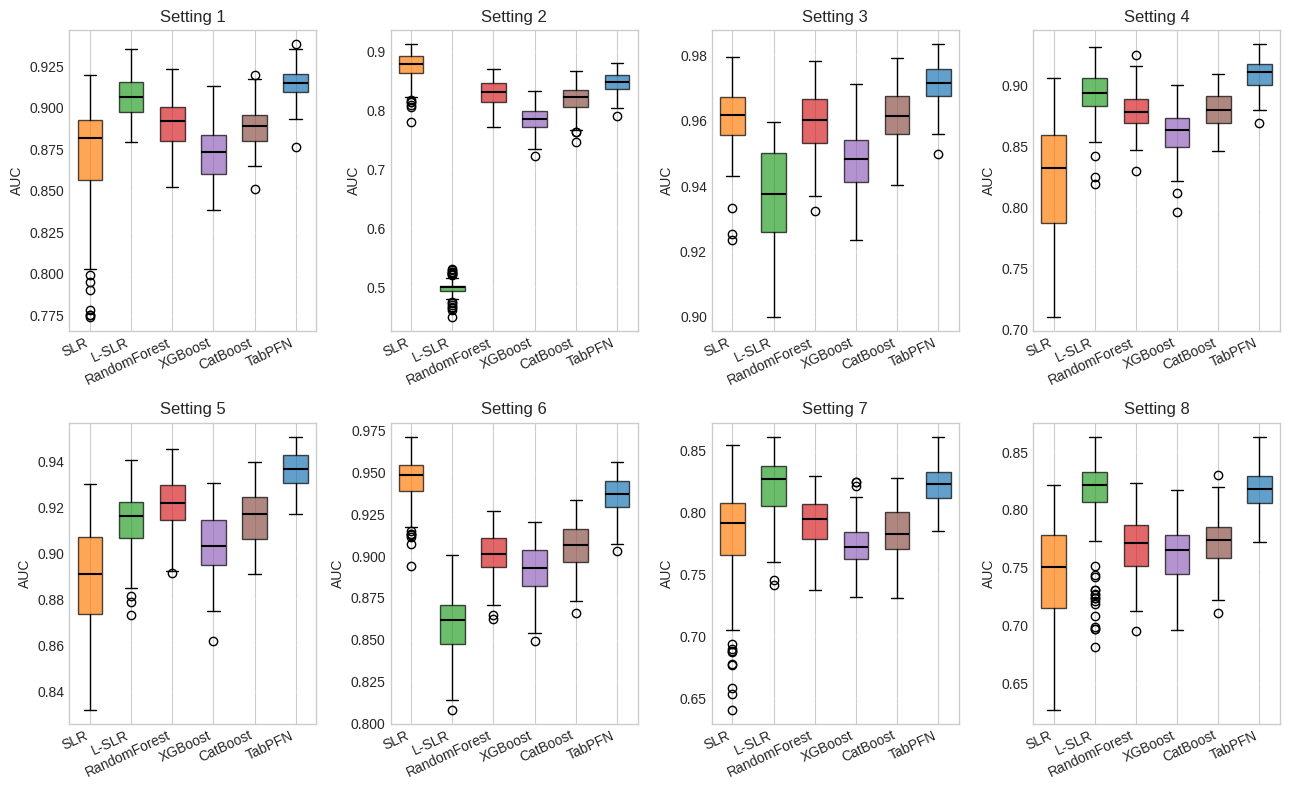

In [ ]:
# MSE boxplots grid
plot_boxplots_grid_lands(errors_dict, setting_names, dir=PLOTS_DIR, metric='AUC',
                   figsize=(13, 8), save_path='auc_boxplots_grid_land.png')

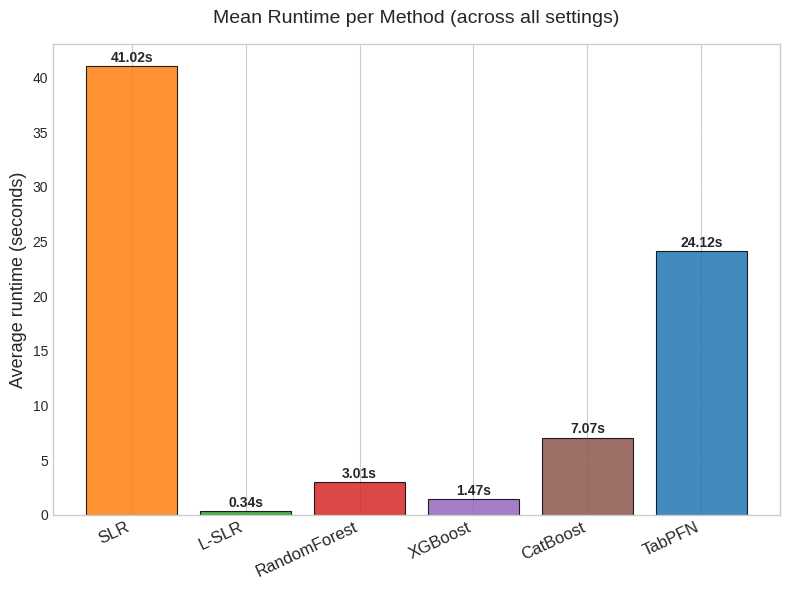

In [ ]:
plot_runtime_barplot_simple(errors_dict, setting_names, dir=PLOTS_DIR, save_path='runtime_barplot.png')

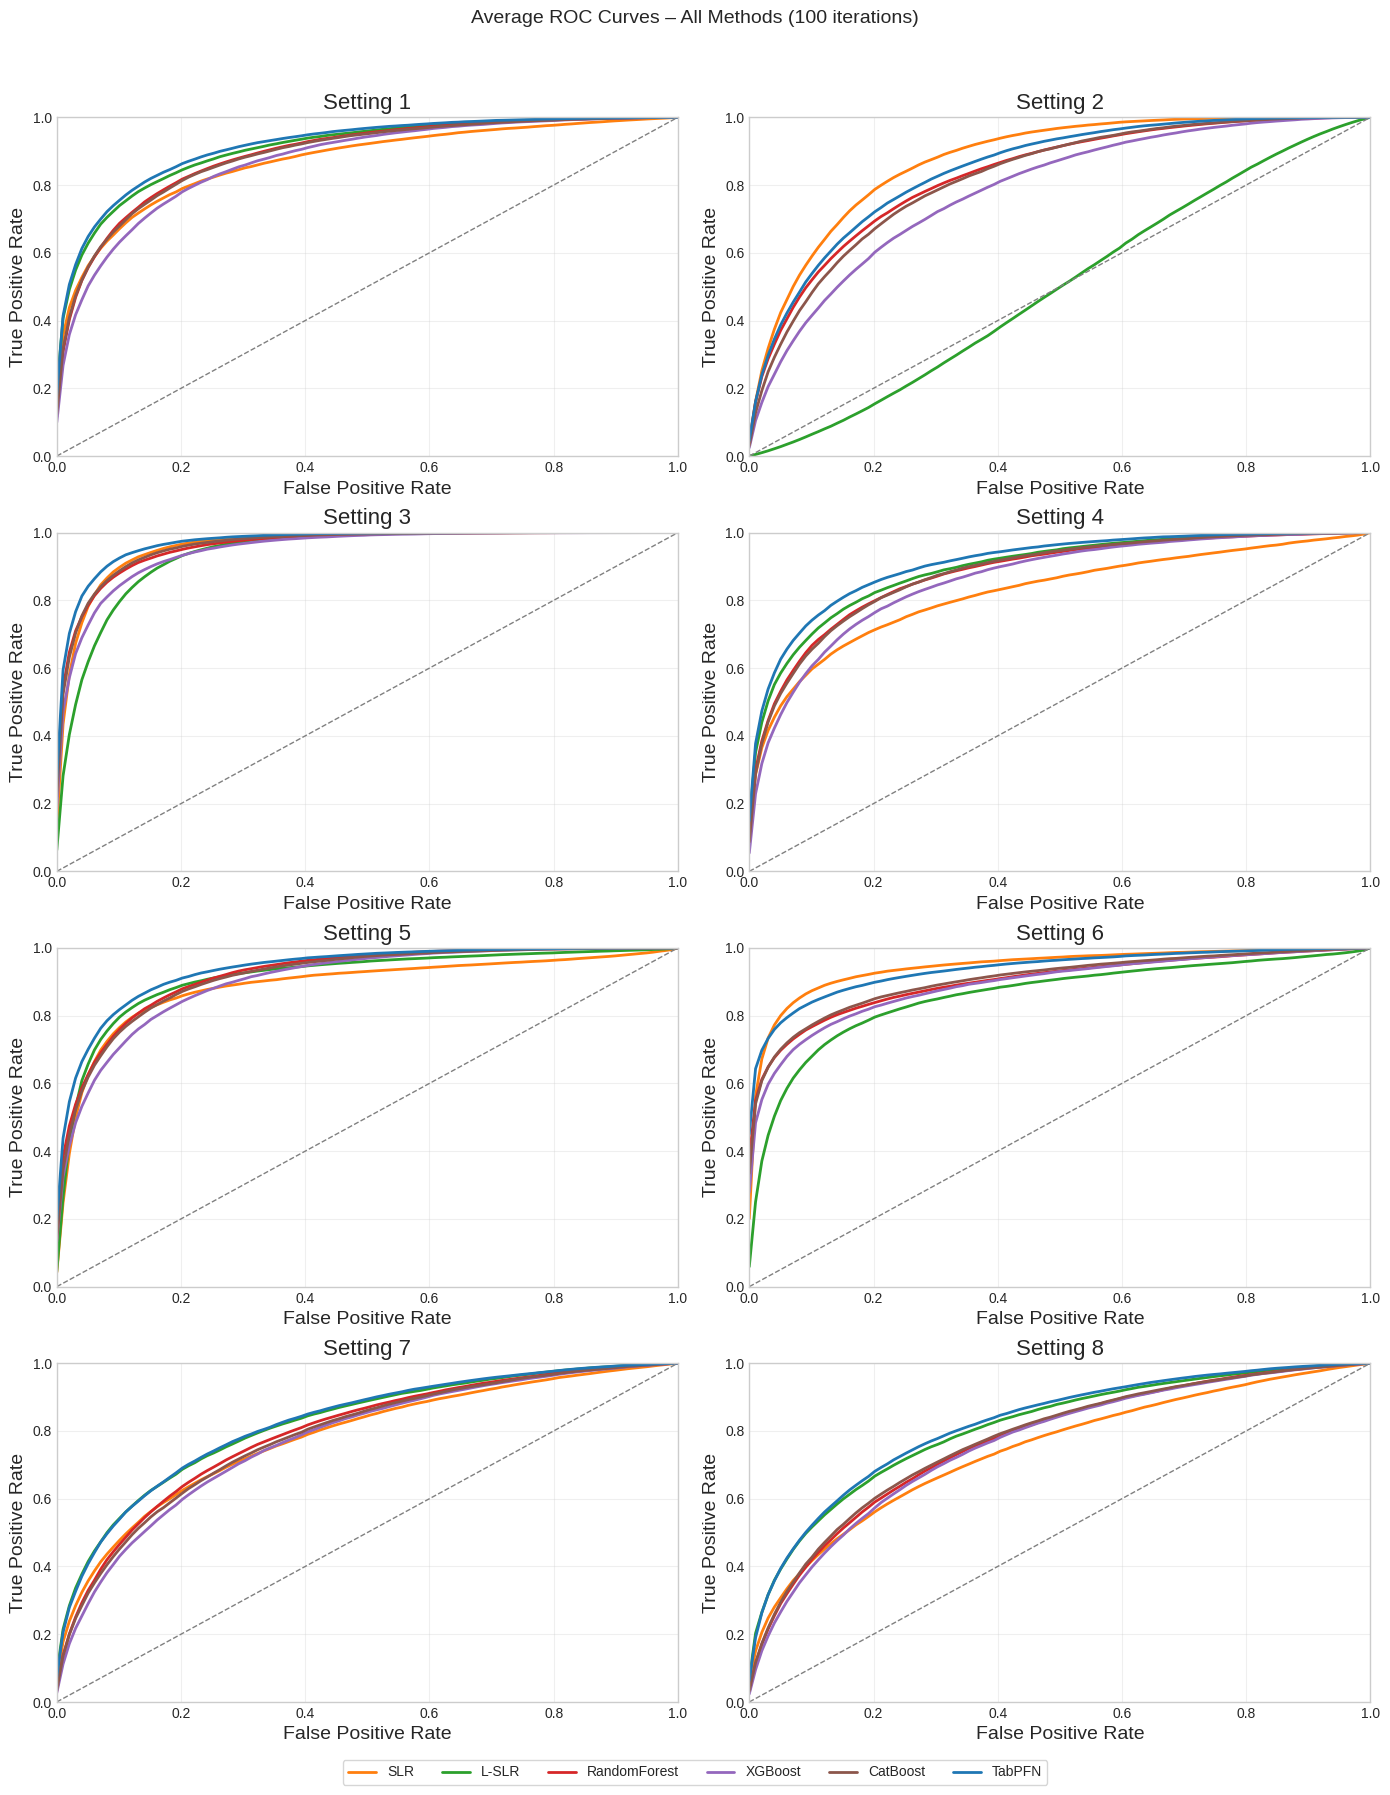

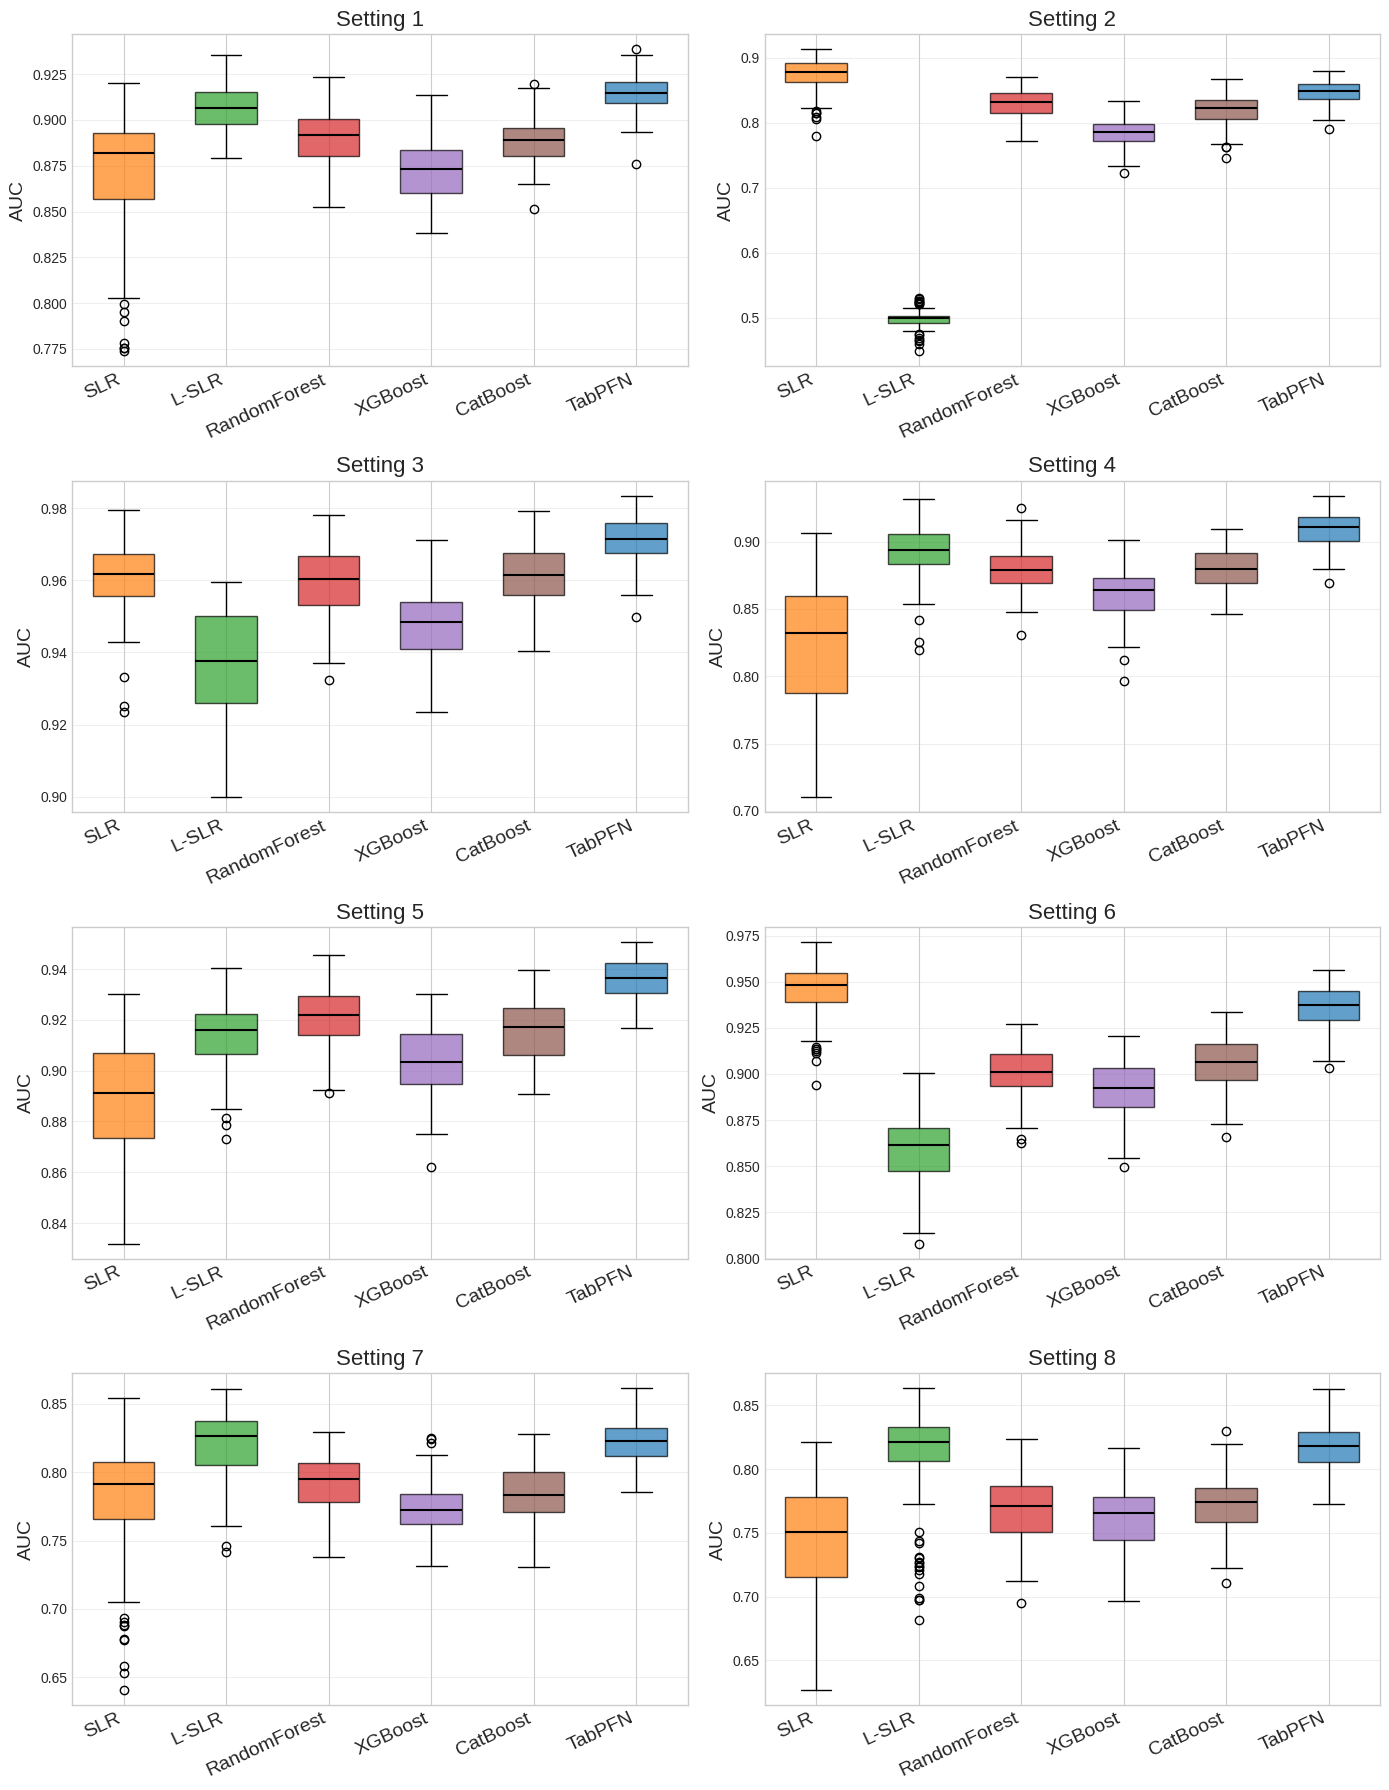

In [ ]:
# AUC boxplots grid
plot_roc_curves_grid(errors_dict, setting_names, dir=PLOTS_DIR,
                     figsize=(14, 18), save_path='roc_curves_grid.png')

plot_boxplots_grid(errors_dict, setting_names, dir=PLOTS_DIR, metric='AUC',
                   figsize=(14, 18), save_path='auc_boxplots_grid.png')

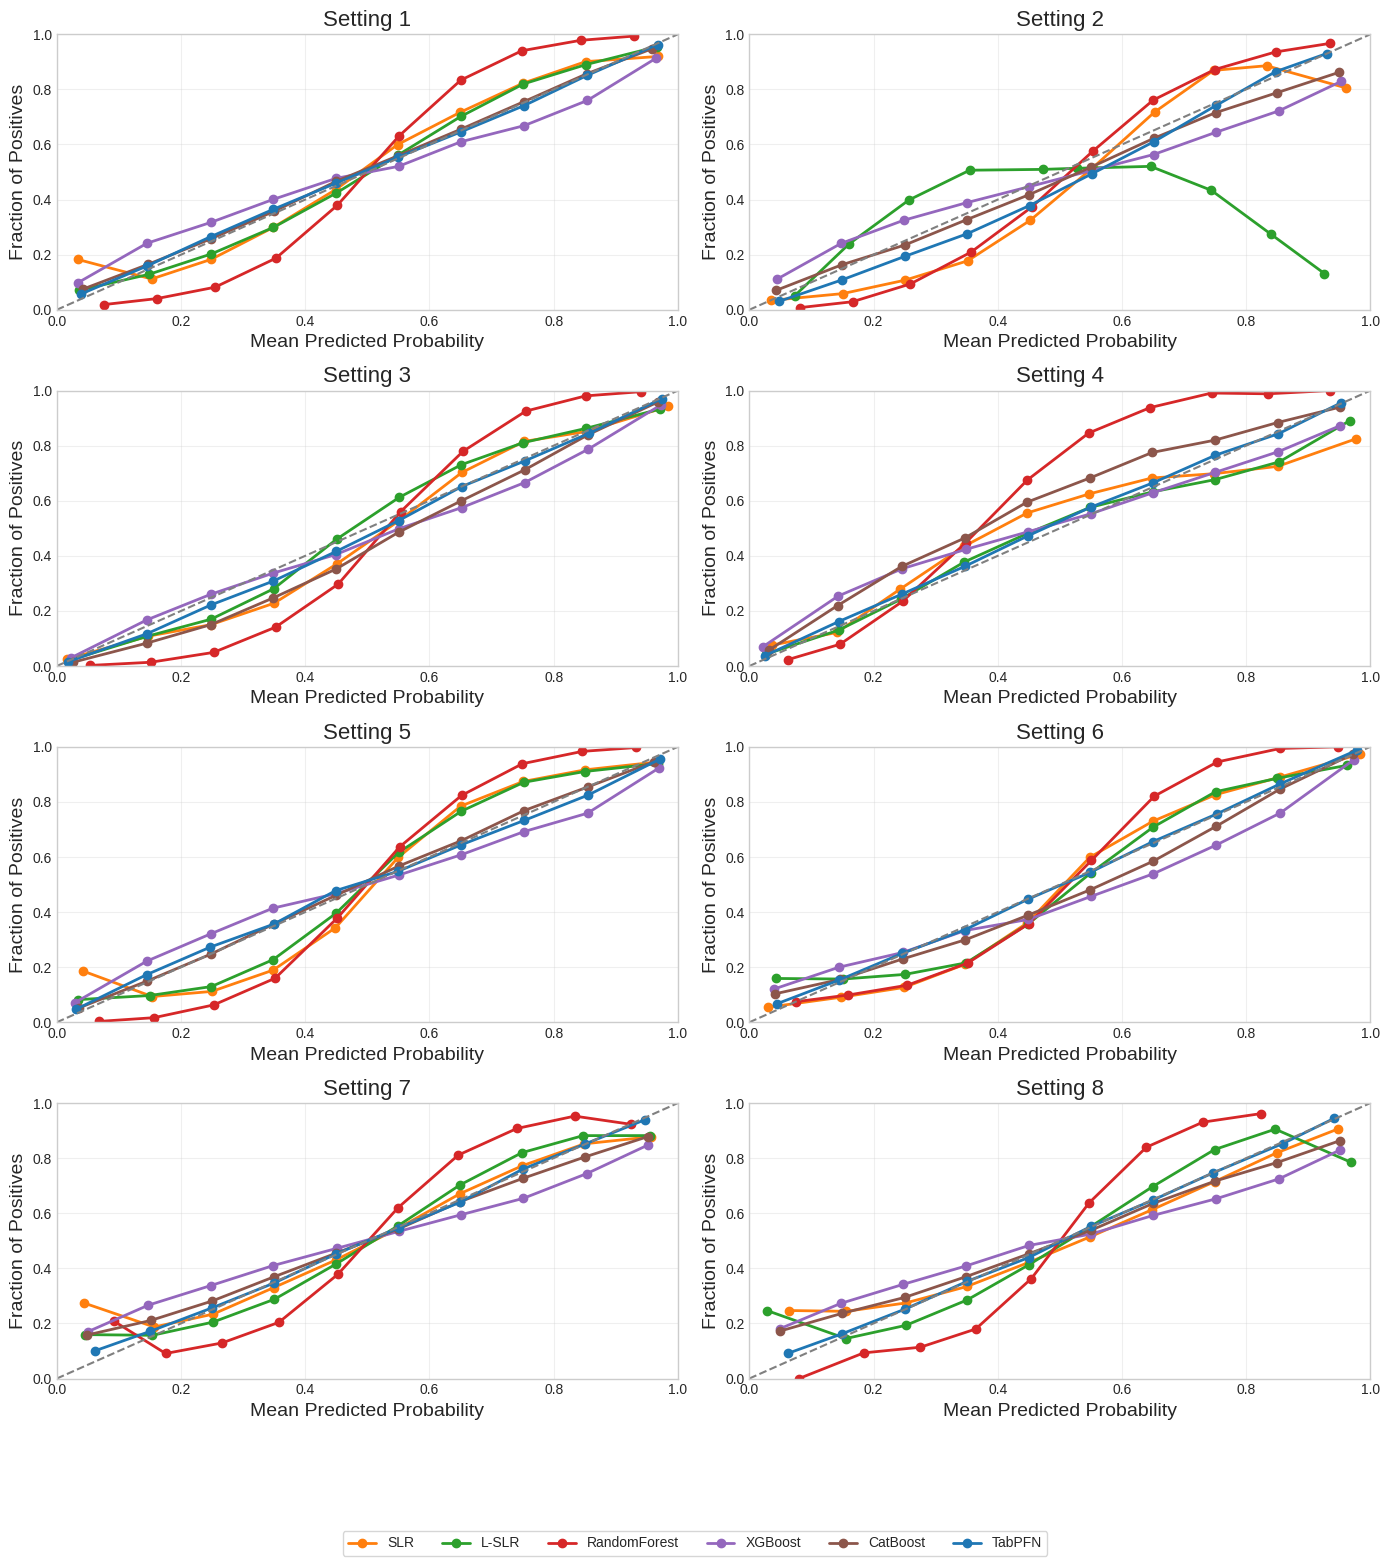

In [ ]:
plot_calibration_grid(errors_dict, setting_names, dir=PLOTS_DIR,
                      figsize=(14, 16), save_path='calibration_grid.png')

#plot_brier_vs_auc_grid(errors_sens_dict, setting_sens_names, dir=PLOTS_DIR,
 #                      figsize=(14, 17), save_path='brier_vs_auc_grid.png')

# Extra (Setting 2 ++)

In [ ]:
# Setting 2 Sensitivity +: Larger Training Sample (500/1000/ per category)
n2_sensitivity_plus = {'n1_tr': 20000, 'n2_tr': 20000, 'n1_te': 500, 'n2_te': 500}

np.random.seed(2027)  # Reset for reproducibility
captured_warnings = []  # Reset warnings for this setting

# Run simulation with increased training size
errors2_sensitivity_plus = simulation(n2_sensitivity_plus, mu2, sigma2_1, sigma2_2,
                                 dist="Normal", iter=10)

# Save simulation info, summary table, and warnings if any
save_simulation_outputs(errors2_sensitivity_plus, captured_warnings,
                        'Setting 2 Sensitivity: Larger Training Sample (n_tr=2000)',
                        n2_sensitivity_plus, mu2, 'Normal', 100,
                        'errors2_sensitivity_plus.csv', 'summary2_sensitivity_plus.csv',
                        'setting2_sensitivity_plus_captured_warnings.csv')

Sim Normal Iterations:   0%|          | 0/10 [00:00<?, ?it/s]
Processing:   0%|          | [00:00<?]
Processing:   0%|          | [00:00<02:02]
Processing:   0%|          | [00:00<02:05]
Processing:   0%|          | [00:00<02:05]
Processing:   0%|          | [00:00<02:06]
Processing:   0%|          | [00:00<02:06]
Processing:   0%|          | [00:00<02:06]
Processing:   1%|          | [00:00<02:06]
Processing:   1%|          | [00:00<02:06]
Processing:   1%|          | [00:00<02:06]
Processing:   1%|          | [00:01<02:06]
Processing:   1%|          | [00:01<02:05]
Processing:   1%|          | [00:01<02:05]
Processing:   1%|          | [00:01<02:05]
Processing:   1%|          | [00:01<02:04]
Processing:   1%|          | [00:01<02:04]
Processing:   1%|▏         | [00:01<02:04]
Processing:   1%|▏         | [00:01<02:04]
Processing:   1%|▏         | [00:01<02:04]
Processing:   2%|▏         | [00:01<02:04]
Processing:   2%|▏         | [00:02<02:03]
Processing:   2%|▏         | [00:02<02:

In [ ]:
# when in setting 2 TabPFN can win?
errors2_sensitivity_plus_from_file = pd.read_csv('errors2_sensitivity_plus.csv', index_col=0)
summary2_sensitivity_plus_from_file = pd.read_csv('summary2_sensitivity_plus.csv', index_col=0)

# Fix DataFrames
errors2_sens_plus_fixed = fix_list_columns(errors2_sensitivity_plus_from_file)

# For Setting 2+
setting_plus = ['Setting 2']
summary_plus = {'Setting 2': summary2_sensitivity_plus_from_file,}
errors_dict = {'Setting 2': errors2_sens_plus_fixed}

RESULTS_DIR = '/content/drive/MyDrive/Colab Notebooks/20250727_tabpfn_[paper]/results/'

combined_auc_brier_sens = build_auc_brier_table(
    summary_dfs=[summary2_sensitivity_plus_from_file],   # direct list
    errors_list=[errors2_sens_plus_fixed],
    setting_names=setting_plus,
    dir=RESULTS_DIR,
    filename='combined_auc_brier_sens.csv'
)

display(combined_auc_brier_sens)

✓ Saved AUC+Brier table to /content/drive/MyDrive/Colab Notebooks/20250727_tabpfn_[paper]/results/combined_auc_brier_sens.csv
